In [17]:
# to make the refactoring easier

In [18]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [19]:
# all imports here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import neoscore as nsc

#new s3m loader
import s3m_loader as load_s3m

import importlib
from functools import reduce
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GCRS, GeocentricTrueEcliptic
from astroML.density_estimation import EmpiricalDistribution
from math import lgamma
import gc

from tqdm import tqdm

## ------------------------------------------------------------------------------- 

### All populations from s3m loaded in

In [20]:
s3m = load_s3m.define_s3m("mba", verbose=True)  # defaults to pop="mba"
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [21]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


In [22]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


In [23]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


## ------------------------------------------------------------------------------- 

### section to compute apparent magnitude for full population on the full sky

In [24]:
def compute_apparent_magnitude_for_population(
    df,
    obstime_str,
    scorer,
    chunk=100_000,
    show_progress=False,
):
    """
    Compute apparent magnitude for every object in the full population df
    at obstime_str, BEFORE any sky-position cut.
    """

    AU_KM = 149597870.7

    # propagate all rows in df
    r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=df["a"].to_numpy(dtype=float),
        e=df["e"].to_numpy(dtype=float),
        inc_deg=df["i"].to_numpy(dtype=float),
        raan_deg=df["node"].to_numpy(dtype=float),
        argp_deg=df["argperi"].to_numpy(dtype=float),
        tp_mjd=df["t_p"].to_numpy(dtype=float),
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # rotate ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_eq = np.column_stack([
        r_ecl[:, 0],
        c * r_ecl[:, 1] - s * r_ecl[:, 2],
        s * r_ecl[:, 1] + c * r_ecl[:, 2],
    ])

    # Earth heliocentric state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    r_helio_vec = r_eq
    r_obs_vec = r_eq - (rE + r_tele)
    
    r_sun = np.linalg.norm(r_helio_vec, axis=1)
    Delta = np.linalg.norm(r_obs_vec, axis=1)
    
    if np.nanmedian(r_sun) > 1000:
        r_sun = r_sun / AU_KM
        Delta = Delta / AU_KM
    
    u_sun = -r_helio_vec / np.linalg.norm(r_helio_vec, axis=1, keepdims=True)
    u_obs = -r_obs_vec / np.linalg.norm(r_obs_vec, axis=1, keepdims=True)

    cos_alpha = np.sum(u_sun * u_obs, axis=1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha = np.arccos(cos_alpha)

    # HG phase function
    G = 0.15
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
    Phi = (1 - G) * phi1 + G * phi2
    Phi = np.maximum(Phi, 1e-30)

    H = df["H"].to_numpy(dtype=float)

    mag_app = H + 5.0 * np.log10(r_sun * Delta) - 2.5 * np.log10(Phi)
    return mag_app

In [25]:
def select_df_by_mag_bin(df, mag_app, mag_min=None, mag_max=None):
    """
    Select rows directly from the full population df using apparent magnitude.
    """
    sel = np.isfinite(mag_app)

    if mag_min is not None:
        sel &= (mag_app >= mag_min)

    if mag_max is not None:
        sel &= (mag_app < mag_max)

    df_sel = df.loc[sel].copy()
    mag_sel = mag_app[sel]

    return df_sel, mag_sel
    # df_sel here is magnitude filtered but whole sky

## ------------------------------------------------------------------------------- 

### helper functions
#### so mean_anomaly_deg_at_obstime and mean_longitude_deg_at_obstime are not doing anything for the cloner — they are purely for annotating visible_df with M_obs_deg and L_obs_deg columns. Those columns end up in visible_df and are available for diagnostics and plots (e.g. checking the phase distribution of the visible subset), but the cloner recomputes M_obs itself from scratch from t_p and a so it does not actually read those columns.

#### build_visible_subset_dataframe calls them to annotate the output dataframe.

In [26]:
def wrap360_deg(x):
    return np.mod(x, 360.0)

def mean_anomaly_deg_at_obstime(a_AU, tp_mjd, obstime_str):
    t_obs = Time(obstime_str, scale="tdb")
    a_AU = np.asarray(a_AU, dtype=float)
    tp_mjd = np.asarray(tp_mjd, dtype=float)
    a_km = a_AU * AU_km
    n_rad_s = np.sqrt(mu_sun / a_km**3)
    n_rad_day = n_rad_s * 86400.0
    M_rad = n_rad_day * (t_obs.mjd - tp_mjd)
    return wrap360_deg(np.rad2deg(M_rad))

def mean_longitude_deg_at_obstime(a_AU, node_deg, argperi_deg, tp_mjd, obstime_str):
    M_deg = mean_anomaly_deg_at_obstime(a_AU, tp_mjd, obstime_str)
    return wrap360_deg(node_deg + argperi_deg + M_deg)

### Sky patch cut and orbital phase

In [66]:
# lets see if this fixes bug -- maybe did
# currently passing df_sel so the mag filtered df not the whole population
def build_visible_subset_dataframe(
    df,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    """
    Propagate the ORIGINAL dataframe to obstime_str, apply the sky cut,
    and return a dataframe of only the objects that survive.

    Adds:
        M_obs_deg
        L_obs_deg
        ra_deg
        dec_deg
        dra_deg_day
        ddec_deg_day
        vlam
        vbeta
        sky_sep_deg
    """
    t_obs = Time(obstime_str, scale="tdb")

    # original row indices so we can map mask -> dataframe rows
    orig_idx = np.arange(len(df), dtype=int)

    # orbital elements from dataframe
    a_AU = df["a"].to_numpy(dtype=float)
    e = df["e"].to_numpy(dtype=float)
    inc = df["i"].to_numpy(dtype=float)
    raan = df["node"].to_numpy(dtype=float)
    argp = df["argperi"].to_numpy(dtype=float)
    tp_mjd = df["t_p"].to_numpy(dtype=float)

    # heliocentric ecliptic state from existing pipeline
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and rates in equatorial frame
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x * x + y * y
    r2 = rho2 + z * z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x * vy - y * vx) / rho2
    ddec = (vz * rho2 - z * (x * vx + y * vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        np.isfinite(rho2) & (rho2 > 0) &
        np.isfinite(r2) & (r2 > 0) &
        np.isfinite(rho) & (rho > 0)
    )

    orig_idx_good = orig_idx[good]

    ra_deg = np.rad2deg(ra[good]) % 360.0
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs),
    )

    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sky_sep_deg = sc.separation(center_sc).deg
    m = sky_sep_deg <= max_sep_deg

    # selected rows in original dataframe
    sel_idx = orig_idx_good[m]
    out = df.iloc[sel_idx].copy().reset_index(drop=True)

    out["ra_deg"] = ra_deg[m]
    out["dec_deg"] = dec_deg[m]
    out["dra_deg_day"] = dra_deg_day[m]
    out["ddec_deg_day"] = ddec_deg_day[m]
    out["sky_sep_deg"] = sky_sep_deg[m]

    # selected relative state vectors in equatorial frame
    r_rel_sel = r_rel[good][m]
    v_rel_sel = v_rel[good][m]

    # rotate equatorial -> ecliptic
    x_ecl = r_rel_sel[:, 0]
    y_ecl = c * r_rel_sel[:, 1] + s * r_rel_sel[:, 2]
    z_ecl = -s * r_rel_sel[:, 1] + c * r_rel_sel[:, 2]

    vx_ecl = v_rel_sel[:, 0]
    vy_ecl = c * v_rel_sel[:, 1] + s * v_rel_sel[:, 2]
    vz_ecl = -s * v_rel_sel[:, 1] + c * v_rel_sel[:, 2]

    rho2_ecl = x_ecl * x_ecl + y_ecl * y_ecl
    r2_ecl = rho2_ecl + z_ecl * z_ecl
    rho_ecl = np.sqrt(rho2_ecl)

    lam = np.arctan2(y_ecl, x_ecl)
    beta = np.arctan2(z_ecl, rho_ecl)

    dlam = (x_ecl * vy_ecl - y_ecl * vx_ecl) / rho2_ecl
    dbeta = (vz_ecl * rho2_ecl - z_ecl * (x_ecl * vx_ecl + y_ecl * vy_ecl)) / (r2_ecl * rho_ecl)

    out["lam_deg"] = np.rad2deg(lam) % 360.0
    out["beta_deg"] = np.rad2deg(beta)
    out["vlam"] = np.rad2deg(dlam) * 86400.0
    out["vbeta"] = np.rad2deg(dbeta) * 86400.0

    # phase like quantities at this obstime
    out["M_obs_deg"] = mean_anomaly_deg_at_obstime(
        out["a"].to_numpy(),
        out["t_p"].to_numpy(),
        obstime_str,
    )

    out["L_obs_deg"] = mean_longitude_deg_at_obstime(
        out["a"].to_numpy(),
        out["node"].to_numpy(),
        out["argperi"].to_numpy(),
        out["t_p"].to_numpy(),
        obstime_str,
    )

    return out

### cloning w mean anomaly randomisation using astroml 

In [29]:
# always pass df_sel (for mag cut) or out (the output of build_visible_subset_dataframe) not the full raw pop. 
def clone_population_random_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """
    Clone each orbit clone_factor times using an astroML-style empirical
    distribution of mean anomaly M(obstime) measured from the input subset.

    The sampled mean anomalies are restricted to the min/max range of the
    subset after circular unwrapping.

    Returns
    -------
    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_out
    """
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    # always using a directly from df
    a_AU = df["a"].to_numpy(dtype=np.float64)
    e = df["e"].to_numpy(dtype=np.float32)
    inc = df["i"].to_numpy(dtype=np.float32)
    raan = df["node"].to_numpy(dtype=np.float32)
    argp = df["argperi"].to_numpy(dtype=np.float32)
    tp = df["t_p"].to_numpy(dtype=np.float64)

    # repeat fixed elements
    a_rep = np.repeat(a_AU, clone_factor).astype(np.float64)
    e_rep = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

    # mean motion in rad/day
    a_km = a_AU * AU_km
    n_rad_s = np.sqrt(mu_sun / (a_km ** 3))
    n_rad_day = n_rad_s * 86400.0

    # observed/df mean anomaly at obstime
    M_obs = np.mod((t_obs.mjd - tp) * n_rad_day, 2.0 * np.pi)

    # shift the circular distribution so it is not split at 0 / 2pi
    mean_angle = np.mod(np.angle(np.mean(np.exp(1j * M_obs))), 2.0 * np.pi)
    M_shift = np.mod(M_obs - mean_angle, 2.0 * np.pi)

    # subset support in shifted coordinates
    M_min = M_shift.min()
    M_max = M_shift.max()

    # empirical clone in shifted coordinates
    # astroML expects shape (N, D), so use [:, None]
    M_shift_clone = EmpiricalDistribution(M_shift).rvs(len(a_rep))

    # enforce sampled support to stay inside subset min/max
    M_shift_clone = np.clip(M_shift_clone, M_min, M_max)

    # wrap back to [0, 2pi)
    M_clone = np.mod(M_shift_clone + mean_angle, 2.0 * np.pi)

    # repeat mean motion for cloned sample
    n_rep = np.repeat(n_rad_day, clone_factor)

    # choose t_p so that M(obstime) = M_clone
    tp_out = (t_obs.mjd - (M_clone / n_rep)).astype(np.float32)

    return (
        a_rep.astype(np.float32),
        e_rep,
        inc_rep,
        raan_rep,
        argp_rep,
        tp_out,
    )

In [67]:
def clone_population_conditional_K_from_M(
    df,
    clone_factor,
    obstime_str,
    bin_width_deg=10.0,
    unwrap_threshold_deg=180.0,
    rng=None,
    return_diagnostics=False,
):
    """
    Clone each orbit clone_factor times using:

    1. an empirical distribution of mean anomaly M(obstime)
    2. a conditional empirical distribution of
       K = node + argperi given M

    This is designed for Trojan-like populations where preserving the
    M--(node+argperi) relation is important for preserving the sky/XY clump.

    Notes
    -----
    - Input df should be the visible subset (or mag-cut subset), not the full raw pop.
    - This function returns the RAW cloned orbital elements.
    - After cloning, reapply the same sky cut with build_visible_subset_dataframe()
      if you want the final visible cloned sample.

    Parameters
    ----------
    df : pandas.DataFrame
        Input subset with columns:
        a, e, i, node, argperi, t_p
    clone_factor : int
        Number of clones per parent object.
    obstime_str : str
        Observation time string.
    bin_width_deg : float, optional
        Width of M bins for conditional K|M sampling.
    unwrap_threshold_deg : float, optional
        Values of K below this threshold are shifted by +360 before
        conditional sampling, to keep the parent relation continuous.
    rng : numpy.random.Generator, optional
        Random generator.
    return_diagnostics : bool, optional
        If True, also return a dict of diagnostic arrays.

    Returns
    -------
    a_rep, e_rep, inc_rep, raan_rep, argp_new, tp_out
        Cloned orbital elements.
    diagnostics : dict, optional
        Returned only if return_diagnostics=True.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    # parent arrays
    a_AU = df["a"].to_numpy(dtype=np.float64)
    e = df["e"].to_numpy(dtype=np.float32)
    inc = df["i"].to_numpy(dtype=np.float32)
    raan = df["node"].to_numpy(dtype=np.float32)
    argp = df["argperi"].to_numpy(dtype=np.float32)
    tp = df["t_p"].to_numpy(dtype=np.float64)

    # repeat fixed elements
    a_rep = np.repeat(a_AU, clone_factor).astype(np.float64)
    e_rep = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)

    # mean motion in rad/day
    a_km = a_AU * AU_km
    n_rad_s = np.sqrt(mu_sun / (a_km ** 3))
    n_rad_day = n_rad_s * 86400.0

    # parent mean anomaly at obstime, in radians
    M_obs = np.mod((t_obs.mjd - tp) * n_rad_day, 2.0 * np.pi)

    # circular shift so M is not split at 0 / 2pi
    mean_angle = np.mod(np.angle(np.mean(np.exp(1j * M_obs))), 2.0 * np.pi)
    M_shift = np.mod(M_obs - mean_angle, 2.0 * np.pi)

    # sample clone M from empirical parent M distribution
    M_shift_clone = EmpiricalDistribution(M_shift).rvs(len(a_rep))
    M_clone = np.mod(M_shift_clone + mean_angle, 2.0 * np.pi)

    # repeat mean motion for clone sample
    n_rep = np.repeat(n_rad_day, clone_factor)

    # choose t_p so that M(obstime) = M_clone
    tp_out = (t_obs.mjd - (M_clone / n_rep)).astype(np.float32)

    
    # conditional sampling of K = node + argperi given M
    

    # parent M in degrees
    M_parent_deg = np.rad2deg(M_obs) % 360.0
    M_clone_deg = np.rad2deg(M_clone) % 360.0

    # parent K in degrees
    K_parent_deg = (raan.astype(np.float64) + argp.astype(np.float64)) % 360.0

    # unwrap lower branch so parent relation is continuous
    K_parent_unwrapped = K_parent_deg.copy()
    K_parent_unwrapped[K_parent_unwrapped < unwrap_threshold_deg] += 360.0

    # M bins
    edges = np.arange(0.0, 360.0 + bin_width_deg, bin_width_deg)
    nbins = len(edges) - 1

    # bin parent and clone M
    parent_bin = np.digitize(M_parent_deg, edges) - 1
    parent_bin = np.clip(parent_bin, 0, nbins - 1)

    clone_bin = np.digitize(M_clone_deg, edges) - 1
    clone_bin = np.clip(clone_bin, 0, nbins - 1)

    # store parent K values in each M bin
    K_by_bin = [K_parent_unwrapped[parent_bin == i] for i in range(nbins)]

    # nearest non-empty fallback
    nonempty = np.array([len(v) > 0 for v in K_by_bin])
    nonempty_idx = np.where(nonempty)[0]

    K_clone_unwrapped = np.empty_like(M_clone_deg, dtype=np.float64)

    for j, b in enumerate(clone_bin):
        if len(K_by_bin[b]) == 0:
            nearest = nonempty_idx[np.argmin(np.abs(nonempty_idx - b))]
            draw_from = K_by_bin[nearest]
        else:
            draw_from = K_by_bin[b]

        K_clone_unwrapped[j] = rng.choice(draw_from)

    K_clone_deg = K_clone_unwrapped % 360.0

    # keep node fixed, solve for new argperi
    argp_new = (K_clone_deg - raan_rep.astype(np.float64)) % 360.0
    argp_new = argp_new.astype(np.float32)

    if return_diagnostics:
        diagnostics = {
            "M_parent_deg": M_parent_deg,
            "M_clone_deg": M_clone_deg,
            "K_parent_deg": K_parent_deg,
            "K_parent_unwrapped": K_parent_unwrapped,
            "K_clone_deg": K_clone_deg,
            "K_clone_unwrapped": K_clone_unwrapped,
            "parent_bin": parent_bin,
            "clone_bin": clone_bin,
            "mean_angle_rad": mean_angle,
        }
        return (
            a_rep.astype(np.float32),
            e_rep,
            inc_rep,
            raan_rep,
            argp_new,
            tp_out,
            diagnostics,
        )

    return (
        a_rep.astype(np.float32),
        e_rep,
        inc_rep,
        raan_rep,
        argp_new,
        tp_out,
    )

In [69]:
def clone_population_conditional_K_from_M_with_skycut(
    df,
    clone_factor,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    chunk=100_000,
    show_progress=True,
    bin_width_deg=10.0,
    unwrap_threshold_deg=180.0,
    rng=None,
    return_raw_clone_df=False,
    return_diagnostics=False,
):
    """
    Clone a population using conditional K | M sampling, then reapply
    the same sky cut internally.

    """
    if rng is None:
        rng = np.random.default_rng(0)

    if return_diagnostics:
        (
            a_rep,
            e_rep,
            inc_rep,
            raan_rep,
            argp_rep,
            tp_out,
            diagnostics,
        ) = clone_population_conditional_K_from_M(
            df=df,
            clone_factor=clone_factor,
            obstime_str=obstime_str,
            bin_width_deg=bin_width_deg,
            unwrap_threshold_deg=unwrap_threshold_deg,
            rng=rng,
            return_diagnostics=True,
        )
    else:
        (
            a_rep,
            e_rep,
            inc_rep,
            raan_rep,
            argp_rep,
            tp_out,
        ) = clone_population_conditional_K_from_M(
            df=df,
            clone_factor=clone_factor,
            obstime_str=obstime_str,
            bin_width_deg=bin_width_deg,
            unwrap_threshold_deg=unwrap_threshold_deg,
            rng=rng,
            return_diagnostics=False,
        )

    raw_clone_df = pd.DataFrame({
        "a": a_rep,
        "e": e_rep,
        "i": inc_rep,
        "node": raan_rep,
        "argperi": argp_rep,
        "t_p": tp_out,
    })

    clone_visible_df = build_visible_subset_dataframe(
        raw_clone_df,
        obstime_str=obstime_str,
        scorer=scorer,
        max_sep_deg=max_sep_deg,
        chunk=chunk,
        show_progress=show_progress,
        center_mode=center_mode,
        center_lon_deg=center_lon_deg,
        center_lat_deg=center_lat_deg,
    )

    outputs = [clone_visible_df]

    if return_raw_clone_df:
        outputs.append(raw_clone_df)

    if return_diagnostics:
        outputs.append(diagnostics)

    if len(outputs) == 1:
        return outputs[0]
    return tuple(outputs)

In [31]:
def clone_population_random_mean_anomaly_longitude(df, clone_factor, obstime_str, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    a_AU = df["a"].to_numpy(dtype=np.float64)
    e    = df["e"].to_numpy(dtype=np.float32)
    inc  = df["i"].to_numpy(dtype=np.float32)
    raan = df["node"].to_numpy(dtype=np.float32)
    argp = df["argperi"].to_numpy(dtype=np.float32)
    tp   = df["t_p"].to_numpy(dtype=np.float64)

    a_rep    = np.repeat(a_AU, clone_factor).astype(np.float64)
    e_rep    = np.repeat(e,    clone_factor).astype(np.float32)
    inc_rep  = np.repeat(inc,  clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

    # mean motion
    a_km      = a_AU * AU_km
    n_rad_s   = np.sqrt(mu_sun / (a_km ** 3))
    n_rad_day = n_rad_s * 86400.0

    # use mean longitude L = node + argperi + M (in radians)
    # so it constrains the heliocentric position, not M alone
    M_obs = np.mod((t_obs.mjd - tp) * n_rad_day, 2.0 * np.pi)
    node_rad = np.deg2rad(raan.astype(np.float64))
    argp_rad = np.deg2rad(argp.astype(np.float64))
    L_obs = np.mod(node_rad + argp_rad + M_obs, 2.0 * np.pi)

    # circular-unwrap L so it is not split at 0/2π
    mean_angle = np.angle(np.mean(np.exp(1j * L_obs)))
    L_shift = np.mod(L_obs - mean_angle, 2.0 * np.pi)

    L_min = L_shift.min()
    L_max = L_shift.max()

    # sample L from empirical distribution of visible subset
    L_shift_clone = EmpiricalDistribution(L_shift).rvs(len(a_rep))
    L_shift_clone = np.clip(L_shift_clone, L_min, L_max)
    L_clone = np.mod(L_shift_clone + mean_angle, 2.0 * np.pi)

    # compute M from L for each cloned object:
    # M = L - node - argperi
    node_rep = np.deg2rad(raan_rep.astype(np.float64))
    argp_rep_rad = np.deg2rad(argp_rep.astype(np.float64))
    M_clone = np.mod(L_clone - node_rep - argp_rep_rad, 2.0 * np.pi)

    n_rep = np.repeat(n_rad_day, clone_factor)
    tp_out = (t_obs.mjd - (M_clone / n_rep)).astype(np.float32)

    return (
        a_rep.astype(np.float32),
        e_rep, inc_rep, raan_rep, argp_rep,
        tp_out,
    )

###  4. propagation post cloning 

In [32]:
# using the version created in cloned_ecliptic_scan_magcut.ipynb for the H vs D plots
def elements_to_vlam_vbeta_d_h(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    H_vals,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",   # "custom_ecliptic" or "antisun"
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    """
    Convert orbital elements -> visible vlam, vbeta, d_au, H
    using the same sky-cut logic as elements_to_vlam_vbeta().

    H_vals must be the same length as a_AU/e/inc/raan/argp/tp_mjd.
    """
    t_obs = Time(obstime_str, scale="tdb")
    AU_KM = AU_km

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # distance from observer
    d_raw = np.linalg.norm(r_rel, axis=1)
    if np.nanmedian(d_raw) > 1000:
        d_au_all = d_raw / AU_KM
    else:
        d_au_all = d_raw.copy()

    # RA/Dec and rates
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    d_au_good = d_au_all[good]
    H_good = np.asarray(H_vals, dtype=float)[good]

    # object sky coords in GCRS
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    # choose center of sky cut
    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )

    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))

    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    ra_deg = ra_deg[m]
    dec_deg = dec_deg[m]
    dra_deg_day = dra_deg_day[m]
    ddec_deg_day = ddec_deg_day[m]
    d_au_vis = d_au_good[m]
    H_vis = H_good[m]

    # RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg, dec_deg,
        dra_deg_day, ddec_deg_day,
        obstime_str
    )

    finite = np.isfinite(vlam) & np.isfinite(vbeta) & np.isfinite(d_au_vis) & np.isfinite(H_vis)

    vlam = vlam[finite].astype(np.float32)
    vbeta = vbeta[finite].astype(np.float32)
    d_au_vis = d_au_vis[finite].astype(np.float32)
    H_vis = H_vis[finite].astype(np.float32)

    return vlam, vbeta, d_au_vis, H_vis

In [33]:
#Similar to above but used for the ecliptic-strip scan plots (scanning across ecliptic longitude centers rather than a single patch).
# Returns additional quantities needed for the strip plots.

def elements_to_eclipticstrip_quantities(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    t_obs = Time(obstime_str, scale="tdb")

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x * vy - y * vx) / rho2
    ddec = (vz * rho2 - z * (x * vx + y * vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame=GCRS(obstime=t_obs))

    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    ra_deg = ra_deg[m]
    dec_deg = dec_deg[m]
    dra_deg_day = dra_deg_day[m]
    ddec_deg_day = ddec_deg_day[m]

    sc_sel = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame=GCRS(obstime=t_obs))
    ecl = sc_sel.transform_to(GeocentricTrueEcliptic(obstime=t_obs))

    lam_deg = (ecl.lon.to_value(u.deg) % 360.0).astype(np.float32)
    beta_deg = ecl.lat.to_value(u.deg).astype(np.float32)

    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg,
        dec_deg,
        dra_deg_day,
        ddec_deg_day,
        obstime_str,
    )

    vlam = np.asarray(vlam, dtype=np.float32)
    vbeta = np.asarray(vbeta, dtype=np.float32)

    finite = (
        np.isfinite(lam_deg) &
        np.isfinite(beta_deg) &
        np.isfinite(vlam) &
        np.isfinite(vbeta)
    )

    return {
        "lam_deg": lam_deg[finite],
        "beta_deg": beta_deg[finite],
        "vlam": vlam[finite],
        "vbeta": vbeta[finite],
    }

### global variable BUT for cloning because this pipeline was not complicated enough already

In [34]:
#  Global variables 
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")
max_sep_deg = 30.0
AU_km = 149_597_870.7
mu_sun = 1.32712440018e11

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)

# Grid setup (density map) 
from scipy.spatial import cKDTree

grid_step = 0.01   # change to 0.1 for fast tests or 0.01 for og value
x_grid = np.arange(xlim[0], xlim[1] + grid_step, grid_step)
y_grid = np.arange(ylim[0], ylim[1] + grid_step, grid_step)
X0, Y0 = np.meshgrid(x_grid, y_grid, indexing="xy")
grid_points = np.column_stack((X0.ravel(), Y0.ravel()))

# Density estimator tuning 
k_map = 10
n_d0_grid_map = 400

Nsample = None 
bins = 100

In [35]:
print(np.column_stack)
print(type(np.column_stack))
print(callable(np.column_stack))

<function column_stack at 0x78f73810c360>
<class 'numpy._ArrayFunctionDispatcher'>
True


### 5. Bayesian Density Estimation

### Compute the unnormalised log-posterior over the local spacing d₀ given k sorted nearest-neighbour distances. Implements the 2D Appendix B estimator.

In [36]:
# Based on Appendix B posterior in 2D for one evaluation point

def log_posterior_d0_2d(d0_grid, d_knn):
    """
    Compute the unnormalized log-posterior log p(d0 | d_1,...,d_N)
    for the 2D Appendix B nearest-neighbor Bayesian density estimator.

    Parameters
    ----------
    d0_grid : ndarray, shape (M,)
        Trial values of d0 (local spacing) at which to evaluate the posterior.
        Must be strictly positive.
    d_knn : ndarray, shape (N,)
        Sorted nearest-neighbor distances d_1,...,d_N.

    Returns
    -------
    logp : ndarray, shape (M,)
        Unnormalized log-posterior values on d0_grid.
    """
    # Small d0 = points close to each other, big d0 = points sparse
    d0_grid = np.asarray(d0_grid, dtype=float)
    d_knn = np.asarray(d_knn, dtype=float)

    if np.any(d0_grid <= 0):
        raise ValueError("All d0_grid values must be > 0.")
    if np.any(d_knn <= 0):
        raise ValueError("All nearest-neighbor distances must be > 0.")

    N = len(d_knn)
    k_vals = np.arange(1, N + 1)

    logp = np.zeros_like(d0_grid, dtype=float)

    for i, d0 in enumerate(d0_grid):
        term_sum = 0.0

        for k, dk in zip(k_vals, d_knn):
            # log of:
            # 2 / [ d0 (k-1)! ] * exp(-(dk/d0)^2) * (dk/d0)^(2k-1)
            term = (
                np.log(2.0)
                - np.log(d0)
                - lgamma(k)                      # log((k-1)!)
                - (dk / d0) ** 2
                + (2 * k - 1) * np.log(dk / d0)
            )
            term_sum += term

        logp[i] = term_sum

    return logp

### Normalise a log-posterior sampled on a grid (trapezoid rule, log-shift for stability).

In [37]:
# Normalize posterior sampled on a d0 grid

def normalize_posterior_from_loggrid(d0_grid, logp):
    """
    Normalize a posterior sampled on a d0 grid.

    Parameters
    ----------
    d0_grid : ndarray
        Grid of d0 values.
    logp : ndarray
        Unnormalized log-posterior evaluated on d0_grid.

    Returns
    -------
    p_norm : ndarray
        Normalized posterior p(d0 | data) on the grid,
        such that integral p_norm dd0 = 1.
    """
    d0_grid = np.asarray(d0_grid, dtype=float)
    logp = np.asarray(logp, dtype=float)

    # shift by max for numerical stability
    logp_shift = logp - np.max(logp)
    p_unnorm = np.exp(logp_shift)

    # normalize by trapezoid rule
    norm = np.trapz(p_unnorm, d0_grid)
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("Posterior normalization failed.")

    p_norm = p_unnorm / norm
    return p_norm


### Query a cKDTree for the k nearest neighbours of a single evaluation point. Helper for the density estimator.

In [38]:
#Get nearest-neighbor distances for any tree

def get_knn_distances(tree, x0, y0, k=10):
    """
    Return distances from evaluation point (x0, y0)
    to its k nearest neighbors in the given KD-tree.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from a population's (v_lambda, v_beta) points.
    x0, y0 : float
        Evaluation point coordinates.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    d : ndarray, shape (k,)
        Sorted nearest-neighbor distances.
    idx : ndarray, shape (k,)
        Indices of those neighbors in the original point array.
    """
    q = np.array([[x0, y0]])
    d, idx = tree.query(q, k=k)
    return d[0], idx[0]

### Full posterior density estimate at a single grid point. Builds a d₀ grid, evaluates the posterior, returns posterior-mean density ⟨n₀⟩. Optional return_diagnostics=True for debugging.

In [39]:
# Full-posterior density estimate at one evaluation point

def estimate_density_full_posterior_2d(
    tree,
    x0,
    y0,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=800,
    return_diagnostics=False,
):
    """
    Estimate local 2D density at one evaluation point (x0, y0)
    using the full Appendix B posterior.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points in (v_lambda, v_beta).
    x0, y0 : float
        Evaluation point coordinates.
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor : float, default=5.0
        Lower d0 grid bound is d_1 / d0_min_factor.
    d0_max_factor : float, default=10.0
        Upper d0 grid bound is d_k * d0_max_factor.
    n_d0_grid : int, default=800
        Number of trial d0 points in the posterior grid.
    return_diagnostics : bool, default=False
        If True, also return diagnostic quantities.

    Returns
    -------
    n0_mean : float
        Posterior mean density <n0>.
    
    If return_diagnostics=True, also returns a dict with:
        d_knn, d0_grid, p_d0, d0_map, d0_mean, n0_map, n0_mean
    """
    # nearest-neighbor distances
    d_knn, idx_knn = get_knn_distances(tree, x0, y0, k=k)

    # build d0 grid
    d0_min = d_knn[0] / d0_min_factor
    d0_max = d_knn[-1] * d0_max_factor
    d0_grid = np.logspace(np.log10(d0_min), np.log10(d0_max), n_d0_grid)

    # posterior in d0
    logp_d0 = log_posterior_d0_2d(d0_grid, d_knn)
    p_d0 = normalize_posterior_from_loggrid(d0_grid, logp_d0)

    # convert to density n0 = 1 / (pi d0^2)
    n0_grid = 1.0 / (np.pi * d0_grid**2)

   
    d0_map = d0_grid[np.argmax(p_d0)]
    d0_mean = np.trapz(d0_grid * p_d0, d0_grid)
    n0_map = 1.0 / (np.pi * d0_map**2)
    n0_mean = np.trapz(n0_grid * p_d0, d0_grid)

    if return_diagnostics:
        diag = {
            "d_knn": d_knn,
            "d0_grid": d0_grid,
            "p_d0": p_d0,
            "d0_map": d0_map,
            "d0_mean": d0_mean,
            "n0_map": n0_map,
            "n0_mean": n0_mean,
        }
        return n0_mean, diag

    return n0_mean

### Loop over all grid points and call the single-point estimator. This is the main entry for producing a full density map. Build a cKDTree from the cloned (vlam, vbeta) points first.



In [40]:
# Evaluate full-posterior density on the whole grid

def evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=400,
    show_progress=True,
):
    """
    Evaluate posterior-mean density on a full set of evaluation points.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points.
    grid_points : ndarray, shape (Ngrid, 2)
        Evaluation points [(x0,y0), ...].
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor, d0_max_factor : float
        Factors setting the d0 grid range for each evaluation point.
    n_d0_grid : int, default=400
        Number of d0 samples per evaluation point.
        Use 400 for a first full-map test; increase later if needed.
    show_progress : bool, default=True
        Show tqdm progress bar.

    Returns
    -------
    density_vals : ndarray, shape (Ngrid,)
        Posterior mean density at each evaluation point.
    """
    density_vals = np.empty(len(grid_points), dtype=float)

    iterator = enumerate(grid_points)
    if show_progress:
        iterator = tqdm(iterator, total=len(grid_points), desc="Evaluating density map")

    for i, (x0, y0) in iterator:
        density_vals[i] = estimate_density_full_posterior_2d(
            tree,
            x0,
            y0,
            k=k,
            d0_min_factor=d0_min_factor,
            d0_max_factor=d0_max_factor,
            n_d0_grid=n_d0_grid,
            return_diagnostics=False,
        )

    return density_vals

### Typical usage after cloning:
#### pts_clone = np.column_stack([vlam_clone, vbeta_clone])
#### tree_clone = cKDTree(pts_clone)

#### density_flat = evaluate_density_map_full_posterior_2d(
####    tree_clone, grid_points, k=k_map, n_d0_grid=n_d0_grid_map
#### )
#### density_map = density_flat.reshape(X0.shape)
#### density_downweighted = density_map / clone_factor


## Functions for plots etc. 

#### Loop over all populations in clone_sources, clone with the old uniform-M method (replace the inner call to use the fixed function), compute vlam/vbeta, build density maps, downweight. Returns clone_overlay, clone_density_maps, clone_density_maps_downweighted.

In [41]:
def build_cloned_maps_for_center(
    center_lon_deg,
    center_lat_deg,
    center_label,
    clone_sources,
    obstime_str,
    max_sep_deg,
    rng,
    overlay_max,
    grid_points,
    X0,
    k_map,
    n_d0_grid_map,
):
    clone_overlay = {}
    clone_density_maps = {}
    clone_density_maps_downweighted = {}

    for pop_name, info in clone_sources.items():
        f = info["clone_factor"]
        df = info["df"]

        print(f"\n[{center_label}] Cloning {pop_name} with factor {f}...")

        # sky-patch cut first so cloner sees only visible phase arc
        visible_df = build_visible_subset_dataframe(
            df,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print("  visible after sky cut:", len(visible_df))

        if len(visible_df) == 0:
            empty_map = np.zeros_like(X0, dtype=float)
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
            clone_density_maps[pop_name] = empty_map
            clone_density_maps_downweighted[pop_name] = empty_map
            continue

        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
            visible_df, clone_factor=f, obstime_str=obstime_str, rng=rng
        )
        print("  cloned orbit count:", len(a_rep))

        H_rep = np.repeat(visible_df["H"].to_numpy(dtype=np.float32), f)

        vlam_clone, vbeta_clone, d_au_clone, H_clone = elements_to_vlam_vbeta_d_h(
            a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            H_vals=H_rep,
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print(f"  final cloned visible points: {len(vlam_clone)}")

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new, H_rep
        gc.collect()

        n_overlay = min(overlay_max, len(vlam_clone))
        if n_overlay > 0:
            idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
            clone_overlay[pop_name] = {
                "vlam": vlam_clone[idx_overlay].copy(),
                "vbeta": vbeta_clone[idx_overlay].copy(),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
        else:
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }

        pts_clone = np.column_stack([vlam_clone, vbeta_clone])
        n_visible = len(pts_clone)

        if n_visible < 2:
            print(f"  too few visible points ({n_visible}) to build density map; returning zeros.")
            density_clone_map = np.zeros_like(X0, dtype=float)
            density_downweighted_map = np.zeros_like(X0, dtype=float)

        else:
            k_eff = min(k_map, n_visible - 1)

            if k_eff < 2:
                print(f"  too few visible points ({n_visible}) for stable kNN density; returning zeros.")
                density_clone_map = np.zeros_like(X0, dtype=float)
                density_downweighted_map = np.zeros_like(X0, dtype=float)

            else:
                print(f"  building density map with k_eff = {k_eff} (n_visible = {n_visible})")

                tree_clone = cKDTree(pts_clone)

                density_clone_flat = evaluate_density_map_full_posterior_2d(
                    tree_clone,
                    grid_points,
                    k=k_eff,
                    n_d0_grid=n_d0_grid_map,
                    show_progress=True,
                )

                density_clone_map = density_clone_flat.reshape(X0.shape)
                density_downweighted_map = density_clone_map / f

                del tree_clone, density_clone_flat

        clone_density_maps[pop_name] = density_clone_map
        clone_density_maps_downweighted[pop_name] = density_downweighted_map

        print(f"{pop_name} done.")
        print("  raw cloned max density   :", np.nanmax(density_clone_map))
        print("  downweighted max density :", np.nanmax(density_downweighted_map))

        del vlam_clone, vbeta_clone, d_au_clone, H_clone, pts_clone
        gc.collect()

    density_all_clone_downweighted = (
        clone_density_maps_downweighted["MBA"] +
        clone_density_maps_downweighted["NEO"] +
        clone_density_maps_downweighted["TNO"] +
        clone_density_maps_downweighted["Trojans"]
    )

    return {
        "label": center_label,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "overlay": clone_overlay,
        "density_maps": clone_density_maps,
        "density_maps_downweighted": clone_density_maps_downweighted,
        "density_all_downweighted": density_all_clone_downweighted,
    }

### Same as above but adds a magnitude pre-filter step: calls compute_apparent_magnitude_for_population + select_df_by_mag_bin before cloning. Also stores full_visible cloned points (vlam, vbeta, d_au, H) for science plots.



In [42]:
def clone_population_uniform_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """Old style cloning: uniform random M over [0, 2pi). Use for full population cloning."""
    if rng is None:
        rng = np.random.default_rng(0)
    t_obs = Time(obstime_str, scale="tdb")
    a_AU  = df["a"].to_numpy(dtype=np.float32)
    e     = df["e"].to_numpy(dtype=np.float32)
    inc   = df["i"].to_numpy(dtype=np.float32)
    raan  = df["node"].to_numpy(dtype=np.float32)
    argp  = df["argperi"].to_numpy(dtype=np.float32)
    a_rep    = np.repeat(a_AU, clone_factor).astype(np.float32)
    e_rep    = np.repeat(e,    clone_factor).astype(np.float32)
    inc_rep  = np.repeat(inc,  clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)
    a_km = a_rep.astype(np.float64) * AU_km
    n_rad_s   = np.sqrt(mu_sun / (a_km**3))
    n_rad_day = n_rad_s * 86400.0
    M_rand = rng.uniform(0.0, 2.0 * np.pi, size=len(a_rep)).astype(np.float64)
    tp_new = (t_obs.mjd - (M_rand / n_rad_day)).astype(np.float32)
    return a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new

In [43]:
def build_cloned_maps_for_center_magbin(
    center_lon_deg,
    center_lat_deg,
    center_label,
    clone_sources,
    obstime_str,
    max_sep_deg,
    rng,
    overlay_max,
    grid_points,
    X0,
    k_map,
    n_d0_grid_map,
    mag_min=None,
    mag_max=None,
):
    clone_overlay = {}
    clone_density_maps = {}
    clone_density_maps_downweighted = {}
    magcut_counts = {}

    for pop_name, info in clone_sources.items():
        f = info["clone_factor"]
        df = info["df"]

        print(f"\n[{center_label}] {pop_name} with mag cut {mag_min} to {mag_max}...")

        mag_app = compute_apparent_magnitude_for_population(
            df=df,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            chunk=100_000,
            show_progress=True,
        )

        df_sel, mag_app_cut = select_df_by_mag_bin(
            df=df,
            mag_app=mag_app,
            mag_min=mag_min,
            mag_max=mag_max,
        )

        magcut_counts[pop_name] = len(df_sel)
        print("  objects passing mag cut:", len(df_sel))

        if len(df_sel) == 0:
            empty_map = np.zeros_like(X0, dtype=float)
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
            clone_density_maps[pop_name] = empty_map
            clone_density_maps_downweighted[pop_name] = empty_map
            continue

        # clone from full mag-filtered population with uniform phase
        # (not from visible subset — uniform cloning lets the sky cut
        #  naturally select from all orbit families in the patch)
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_uniform_mean_anomaly(
            df_sel, clone_factor=f, obstime_str=obstime_str, rng=rng
        )
        print("  cloned orbit count:", len(a_rep))

        H_rep = np.repeat(df_sel["H"].to_numpy(dtype=np.float32), f)

        vlam_clone, vbeta_clone, d_au_clone, H_clone = elements_to_vlam_vbeta_d_h(
            a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            H_vals=H_rep,
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print("  final cloned visible points:", len(vlam_clone))

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new, H_rep
        gc.collect()

        n_overlay = min(overlay_max, len(vlam_clone))
        if n_overlay > 0:
            idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
            clone_overlay[pop_name] = {
                "vlam": vlam_clone[idx_overlay].copy(),
                "vbeta": vbeta_clone[idx_overlay].copy(),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
        else:
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }

        pts_clone = np.column_stack([vlam_clone, vbeta_clone])
        n_visible = len(pts_clone)

        if n_visible < 2:
            print(f"  too few visible points ({n_visible}) to build density map; returning zeros.")
            density_clone_map = np.zeros_like(X0, dtype=float)
            density_downweighted_map = np.zeros_like(X0, dtype=float)

        else:
            k_eff = min(k_map, n_visible - 1)

            if k_eff < 2:
                print(f"  too few visible points ({n_visible}) for stable kNN density; returning zeros.")
                density_clone_map = np.zeros_like(X0, dtype=float)
                density_downweighted_map = np.zeros_like(X0, dtype=float)

            else:
                print(f"  building density map with k_eff = {k_eff} (n_visible = {n_visible})")

                tree_clone = cKDTree(pts_clone)

                density_clone_flat = evaluate_density_map_full_posterior_2d(
                    tree_clone,
                    grid_points,
                    k=k_eff,
                    n_d0_grid=n_d0_grid_map,
                    show_progress=True,
                )

                density_clone_map = density_clone_flat.reshape(X0.shape)
                density_downweighted_map = density_clone_map / f

                del tree_clone, density_clone_flat

        clone_density_maps[pop_name] = density_clone_map
        clone_density_maps_downweighted[pop_name] = density_downweighted_map

        print(f"{pop_name} done.")
        print("  raw cloned max density   :", np.nanmax(density_clone_map))
        print("  downweighted max density :", np.nanmax(density_downweighted_map))

        del vlam_clone, vbeta_clone, d_au_clone, H_clone, pts_clone
        gc.collect()

    density_all_clone_downweighted = (
        clone_density_maps_downweighted["MBA"] +
        clone_density_maps_downweighted["NEO"] +
        clone_density_maps_downweighted["TNO"] +
        clone_density_maps_downweighted["Trojans"]
    )

    return {
        "label": center_label,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "mag_min": mag_min,
        "mag_max": mag_max,
        "magcut_counts": magcut_counts,
        "overlay": clone_overlay,
        "density_maps": clone_density_maps,
        "density_maps_downweighted": clone_density_maps_downweighted,
        "density_all_downweighted": density_all_clone_downweighted,
    }

In [44]:
# for reference when calling select_df_by_mag_bin() use 
#df_sel, mag_app_cut = select_df_by_mag_bin(
#    df=df,
#    mag_app=mag_app,
#    mag_min=mag_min,
#    mag_max=mag_max,
#)
# and for build_visible_subset_dataframe
# visible_df = build_visible_subset_dataframe(
#    df_sel,   # <-- pass df_sel here, not df
#    ...
#)
# and
#a_rep, ... = clone_population_random_mean_anomaly(
#    visible_df,   # <-- pass visible_df here, not df_sel
#    ...
#)

### Propagate the raw (uncloned) full population, apply the sky-patch cut, compute vlam, vbeta, d_au, H, and mag_app for the survivors. Used for raw-population scatter plots and diagnostics that do not involve cloning.

In [45]:
def get_raw_patch_selected_sample(
    df,
    scorer,
    obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=20.0,
    chunk=100_000,
    show_progress=True,
):
    """
    Return raw population sample restricted to the selected sky patch, with:
      vlam, vbeta, d_au, H, mag_app
    """

    t_obs = Time(obstime_str, scale="tdb")

    # propagate to heliocentric ecliptic state
    r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=df["a"].to_numpy(dtype=float),
        e=df["e"].to_numpy(dtype=float),
        inc_deg=df["i"].to_numpy(dtype=float),
        raan_deg=df["node"].to_numpy(dtype=float),
        argp_deg=df["argperi"].to_numpy(dtype=float),
        tp_mjd=df["t_p"].to_numpy(dtype=float),
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_eq = np.column_stack([
        r_ecl[:, 0],
        c * r_ecl[:, 1] - s * r_ecl[:, 2],
        s * r_ecl[:, 1] + c * r_ecl[:, 2],
    ])

    v_eq = np.column_stack([
        v_ecl[:, 0],
        c * v_ecl[:, 1] - s * v_ecl[:, 2],
        s * v_ecl[:, 1] + c * v_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative state
    r_rel = r_eq - (rE + r_tele)
    v_rel = v_eq - vE

    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    # sky-patch selection in sky position
    ra_deg = np.rad2deg(ra[good]) % 360.0
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    center_ecl = SkyCoord(
        lon=center_lon_deg * u.deg,
        lat=center_lat_deg * u.deg,
        distance=1.0 * u.AU,
        frame=GeocentricTrueEcliptic(obstime=t_obs),
    )
    center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    good_idx = np.flatnonzero(good)
    patch_idx = good_idx[m]

    # vlam, vbeta for patch sample
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg[m],
        dec_deg[m],
        dra_deg_day[m],
        ddec_deg_day[m],
        obstime_str,
    )

    # distances and H for patch sample
    AU_KM = 149597870.7

    r_obs_vec = r_eq[patch_idx] - (rE + r_tele)
    d_au = np.linalg.norm(r_obs_vec, axis=1) / AU_KM

    H = df["H"].to_numpy(dtype=float)[patch_idx]

    # apparent magnitude for patch sample only
    r_helio_vec = r_eq[patch_idx]
    r_sun = np.linalg.norm(r_helio_vec, axis=1) / AU_KM
    Delta = np.linalg.norm(r_obs_vec, axis=1) / AU_KM

    u_sun = -r_helio_vec / np.linalg.norm(r_helio_vec, axis=1, keepdims=True)
    u_obs = -r_obs_vec / np.linalg.norm(r_obs_vec, axis=1, keepdims=True)

    cos_alpha = np.sum(u_sun * u_obs, axis=1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha = np.arccos(cos_alpha)

    G = 0.15
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
    Phi = (1 - G) * phi1 + G * phi2
    Phi = np.maximum(Phi, 1e-30)

    mag_app = H + 5.0 * np.log10(r_sun * Delta) - 2.5 * np.log10(Phi)

    finite = (
        np.isfinite(vlam) &
        np.isfinite(vbeta) &
        np.isfinite(d_au) &
        np.isfinite(H) &
        np.isfinite(mag_app)
    )

    return {
        "vlam": np.asarray(vlam)[finite],
        "vbeta": np.asarray(vbeta)[finite],
        "d_au": d_au[finite],
        "H": H[finite],
        "mag_app": mag_app[finite],
    }

### extra keys (phase_col, phase_mode, jitter_deg) are only used by clone_visible_subset_by_phase, not by clone_population_random_mean_anomaly so remain unused till switch over

In [46]:
clone_sources = {
    "MBA": {
        "df": s3m,
        "scorer": scorer_mba_s3m,
        "clone_factor": 1,
        "phase_col": "M_obs_deg",
        "phase_mode": "empirical",
        "jitter_deg": 1.0,
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "df": neo,
        "scorer": scorer_neo_s3m,
        "clone_factor": 10,
        "phase_col": "M_obs_deg",
        "phase_mode": "empirical",
        "jitter_deg": 1.0,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "df": tno,
        "scorer": scorer_tno_s3m,
        "clone_factor": 10,
        "phase_col": "M_obs_deg",
        "phase_mode": "empirical",
        "jitter_deg": 1.0,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "df": trojan,
        "scorer": scorer_tjn_s3m,
        "clone_factor": 10,
        "phase_col": "M_obs_deg",
        "phase_mode": "empirical",
        "jitter_deg": 0.5,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

### magnitude bins

In [47]:
mag_bins = [
    {"label": "14_16", "mag_min": 14.0, "mag_max": 16.0},
    {"label": "16_18", "mag_min": 16.0, "mag_max": 18.0},
    {"label": "18_20", "mag_min": 18.0, "mag_max": 20.0},
    {"label": "mag20", "mag_min": 20.0, "mag_max": 21.0},
    {"label": "mag21", "mag_min": 21.0, "mag_max": 22.0},
    {"label": "mag22", "mag_min": 22.0, "mag_max": 23.0},
    {"label": "mag23", "mag_min": 23.0, "mag_max": 24.0},
    {"label": "mag24+", "mag_min": 24.0, "mag_max": 26.0},
]

rng = np.random.default_rng(42)
overlay_max = 200_000

In [31]:
allpop_magbin_results = {}

for mbin in mag_bins:
    print("\n" + "="*80)
    print("Running all populations for mag bin:", mbin["label"])

    allpop_magbin_results[mbin["label"]] = build_cloned_maps_for_center_magbin(
        center_lon_deg=180.0,
        center_lat_deg=0.0,
        center_label="lon180_lat0",
        clone_sources=clone_sources,
        obstime_str=obstime_str,
        max_sep_deg=max_sep_deg,
        rng=rng,
        overlay_max=overlay_max,
        grid_points=grid_points,
        X0=X0,
        k_map=k_map,
        n_d0_grid_map=n_d0_grid_map,
        mag_min=mbin["mag_min"],
        mag_max=mbin["mag_max"],
    )


Running all populations for mag bin: 14_16

[lon180_lat0] MBA with mag cut 14.0 to 16.0...


Propagate with newton: 100%|██████████| 139/139 [00:09<00:00, 15.32it/s]


  objects passing mag cut: 1256
  cloned orbit count: 1256


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 985.97it/s]

  final cloned visible points: 96


...

Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 31.75it/s]


  objects passing mag cut: 25907
  cloned orbit count: 259070


Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 18.75it/s]


  final cloned visible points: 41736
  building density map with k_eff = 10 (n_visible = 41736)


Evaluating density map:  29%|██▉       | 7625/25921 [01:50<04:22, 69.77it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
label = "14_16"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

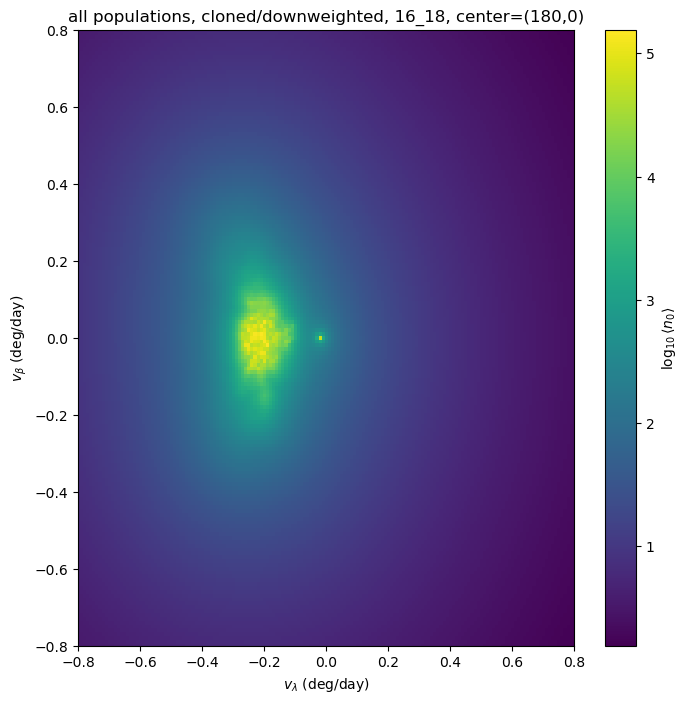

In [33]:
label = "16_18"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

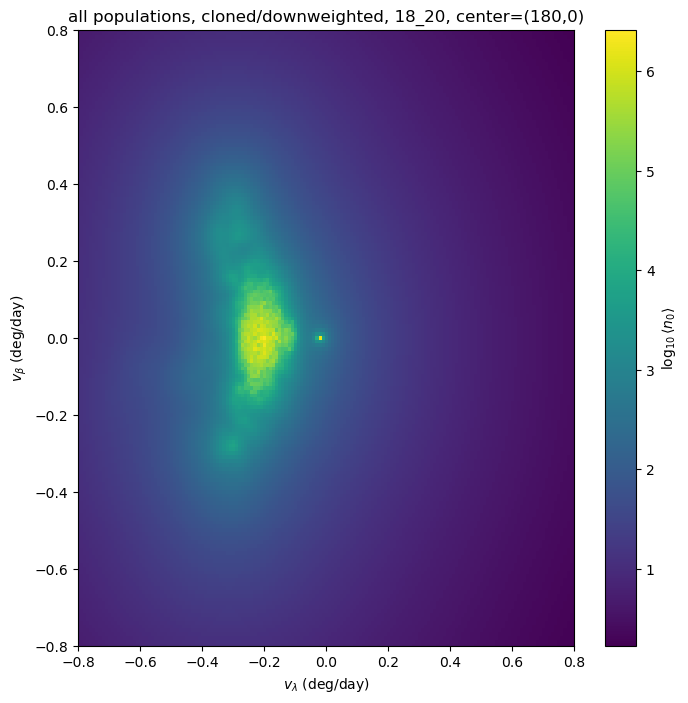

In [34]:
label = "18_20"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

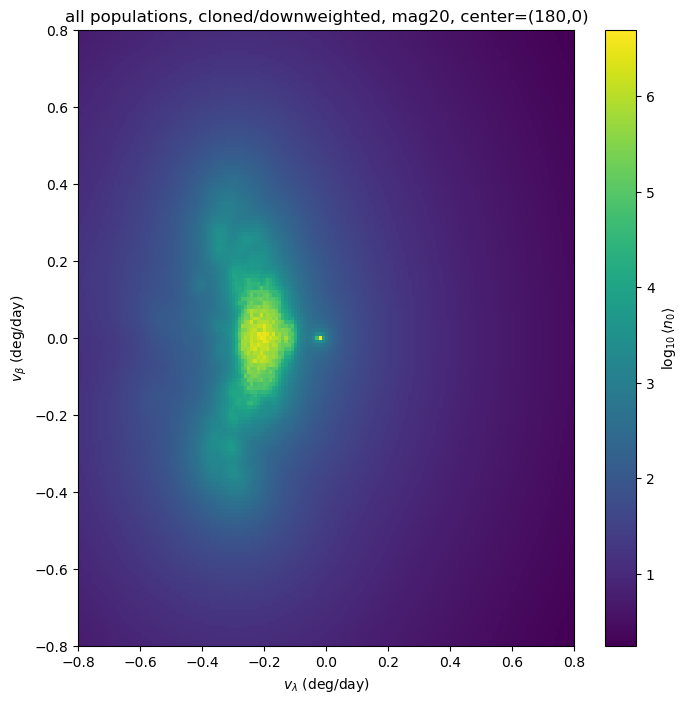

In [35]:
label = "mag20"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

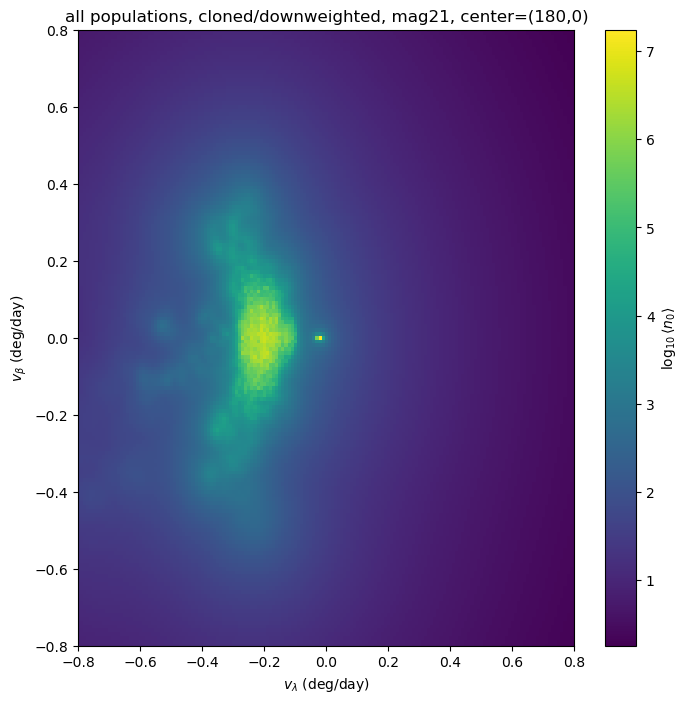

In [36]:
label = "mag21"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

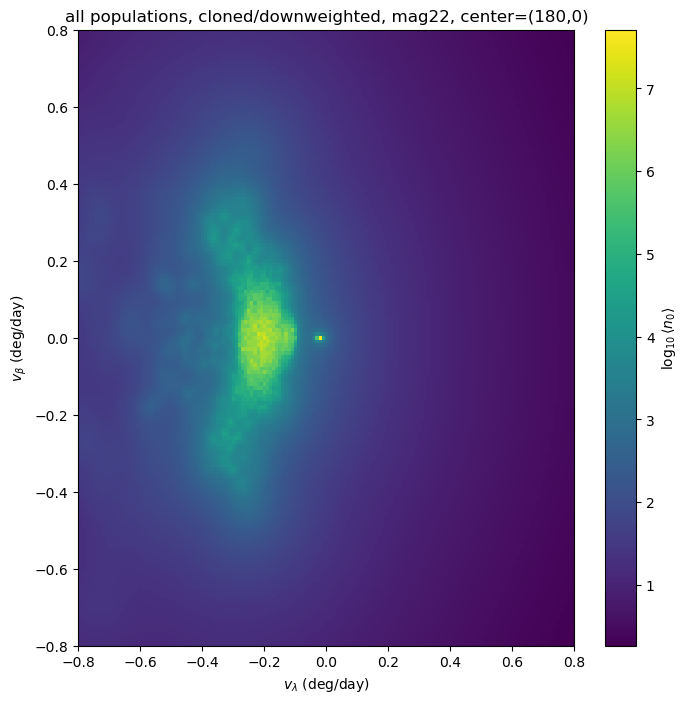

In [37]:
label = "mag22"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

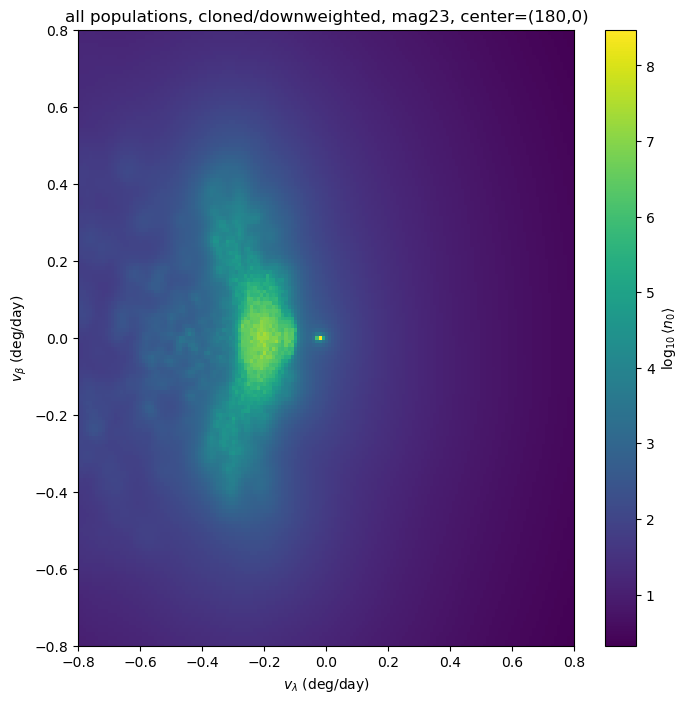

In [38]:
label = "mag23"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

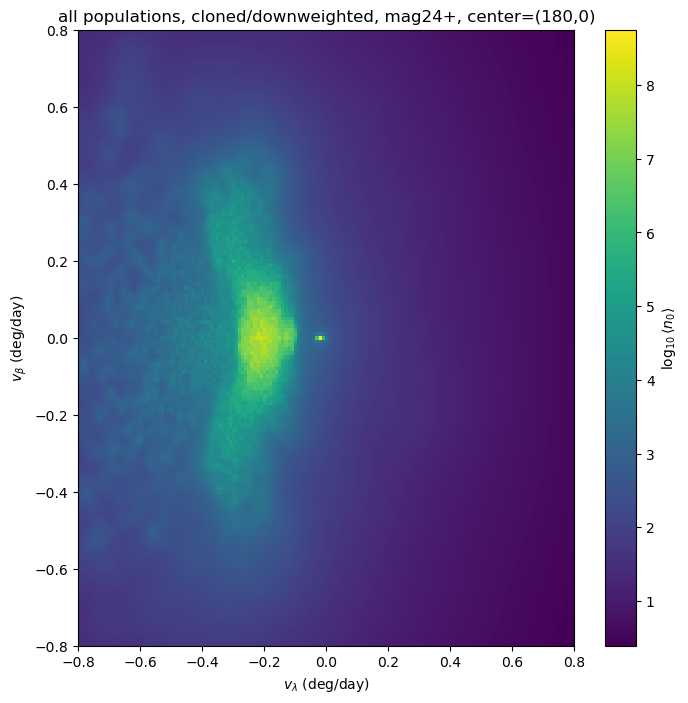

In [39]:
label = "mag24+"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

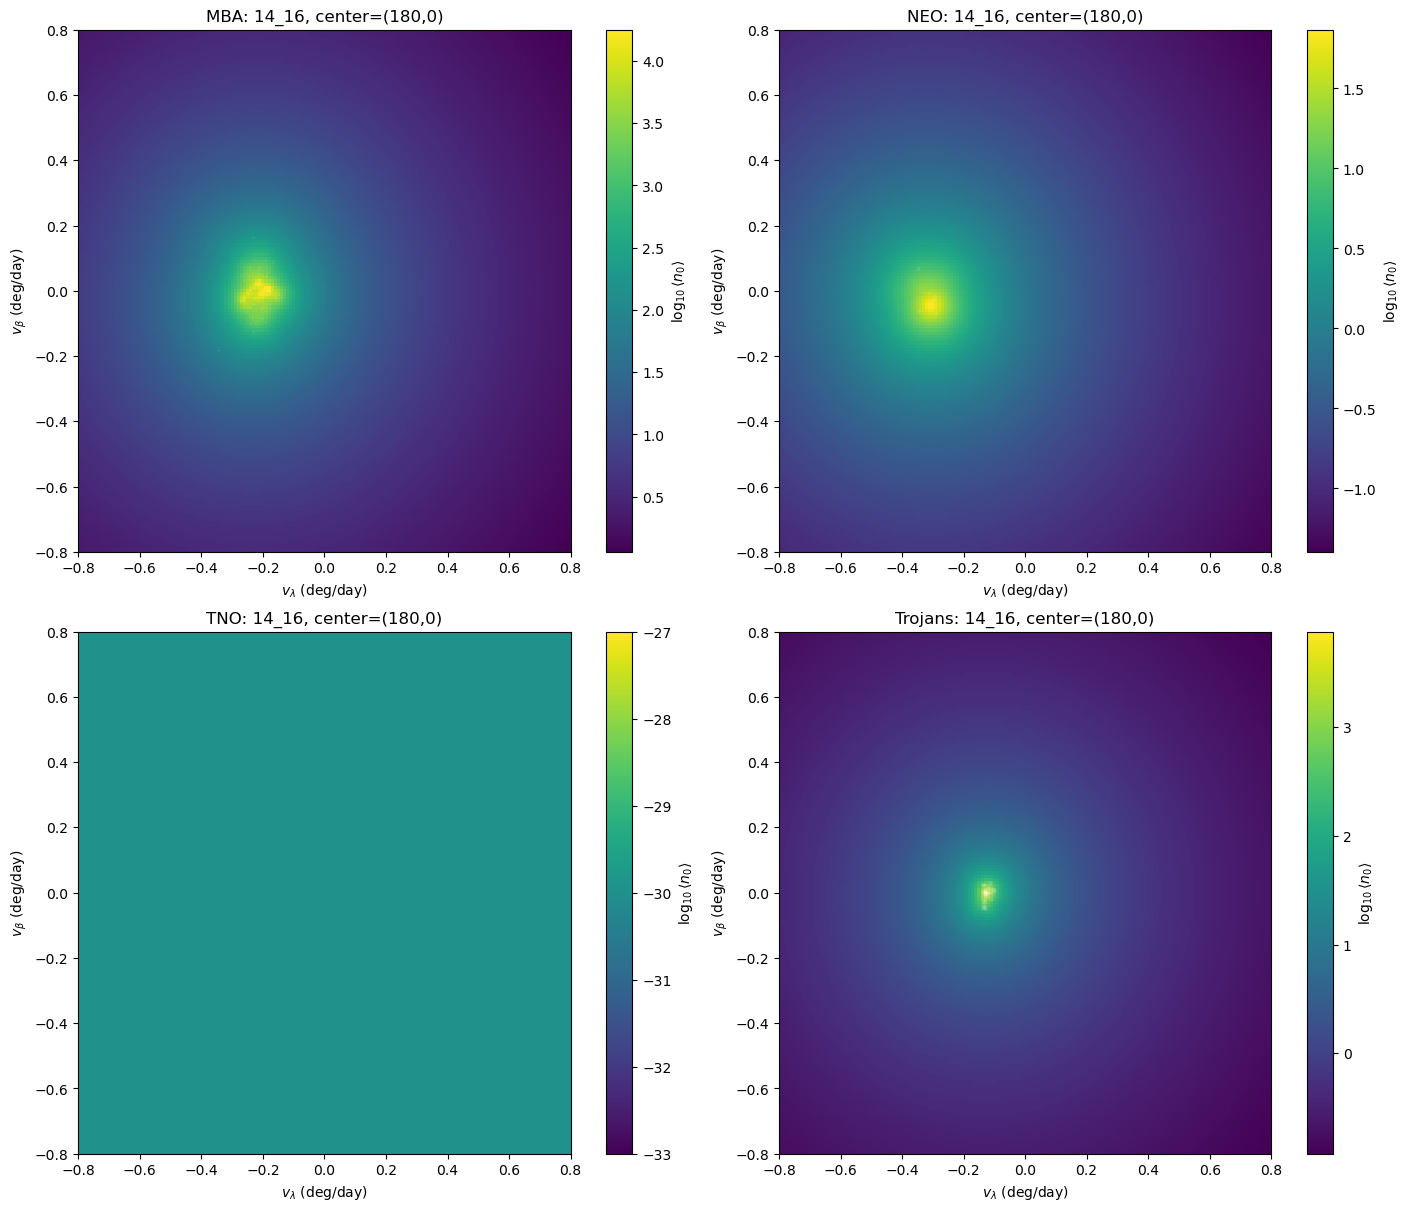

In [40]:
label = "14_16"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

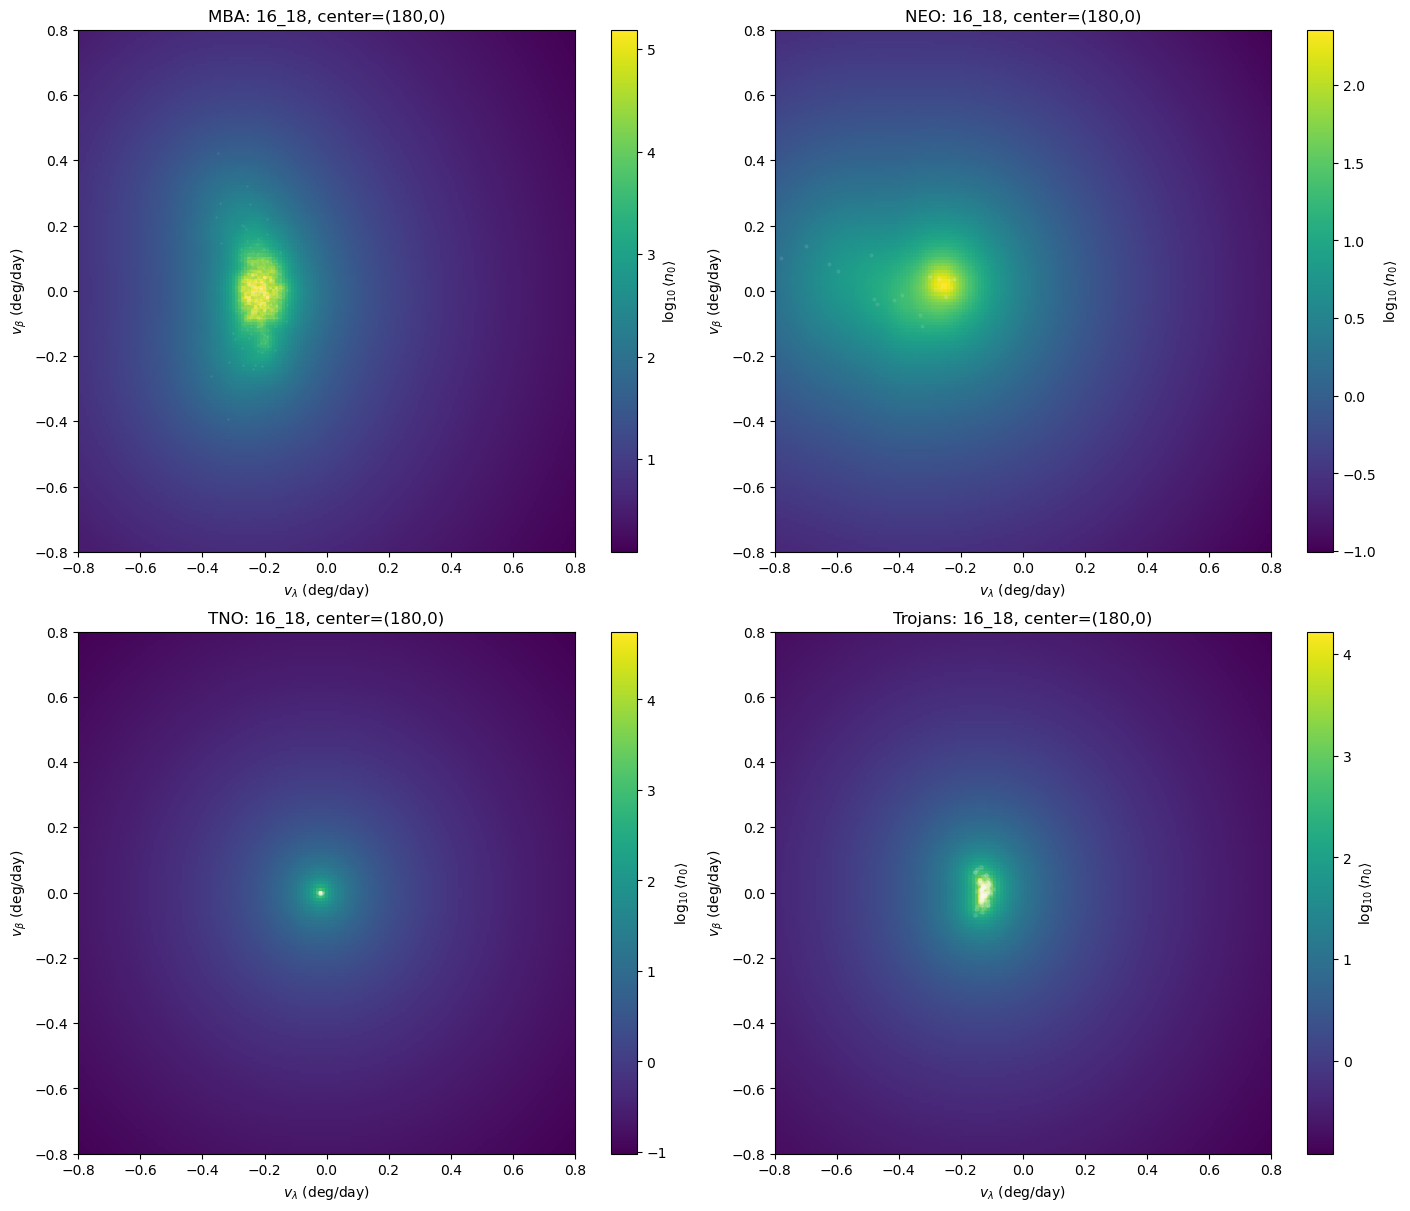

In [41]:
label = "16_18"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

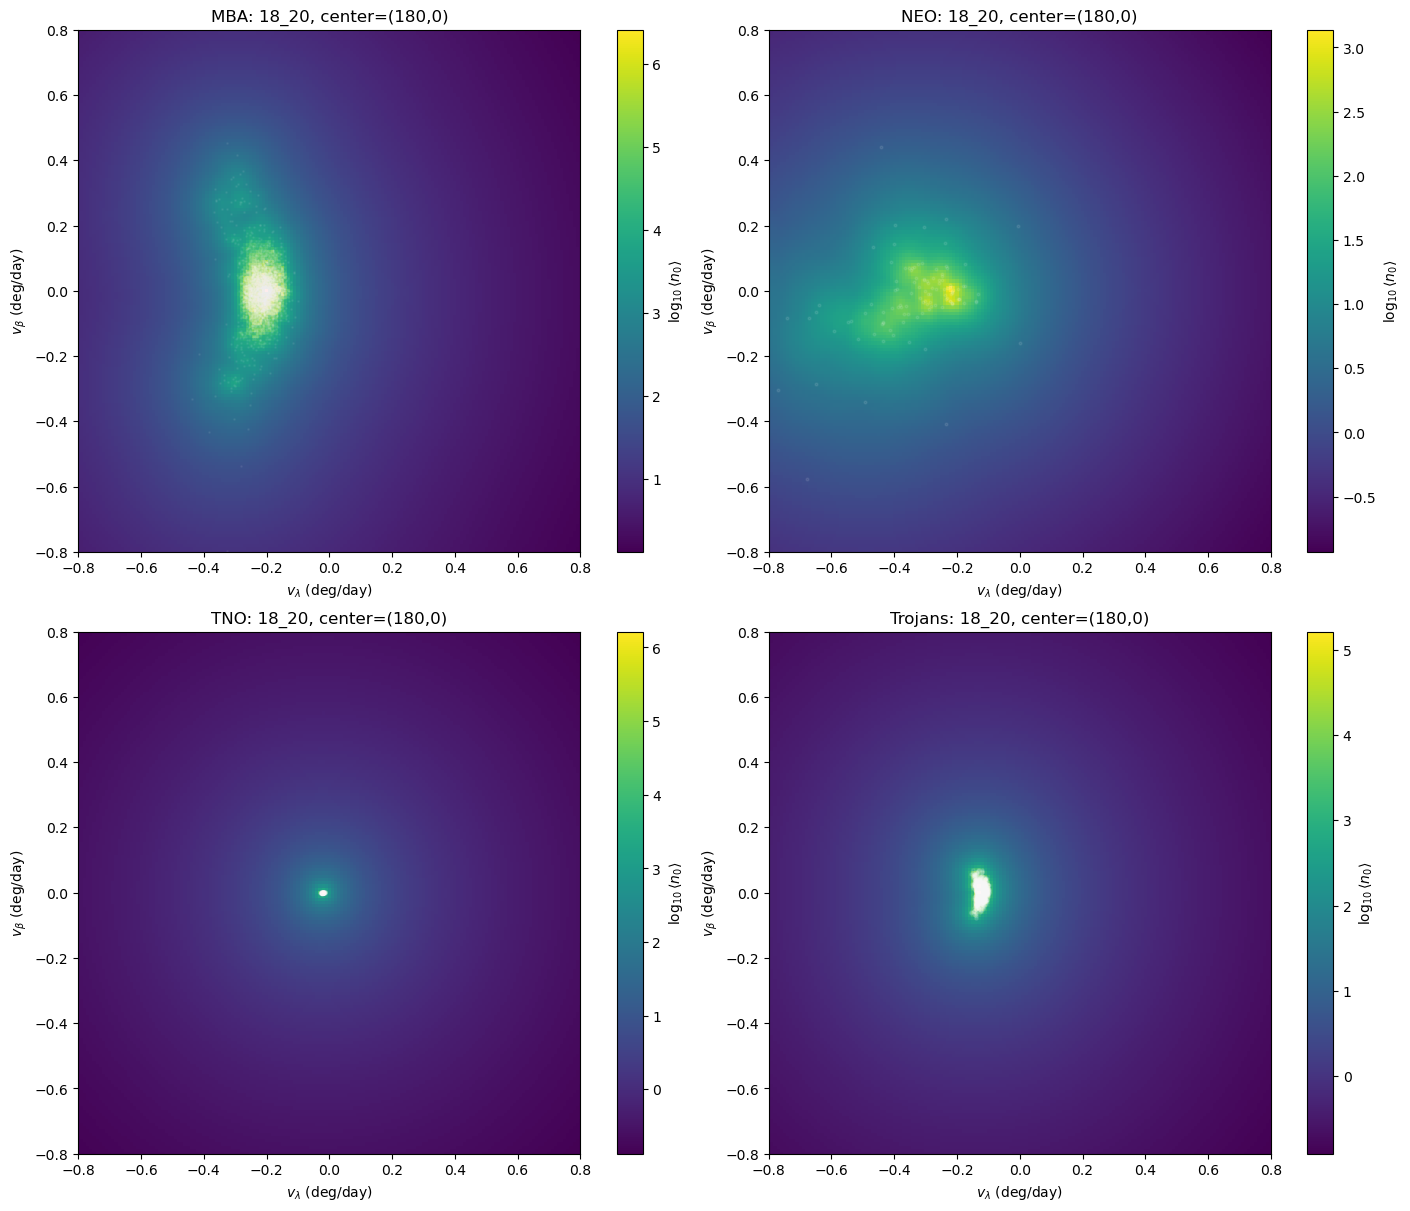

In [42]:
label = "18_20"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

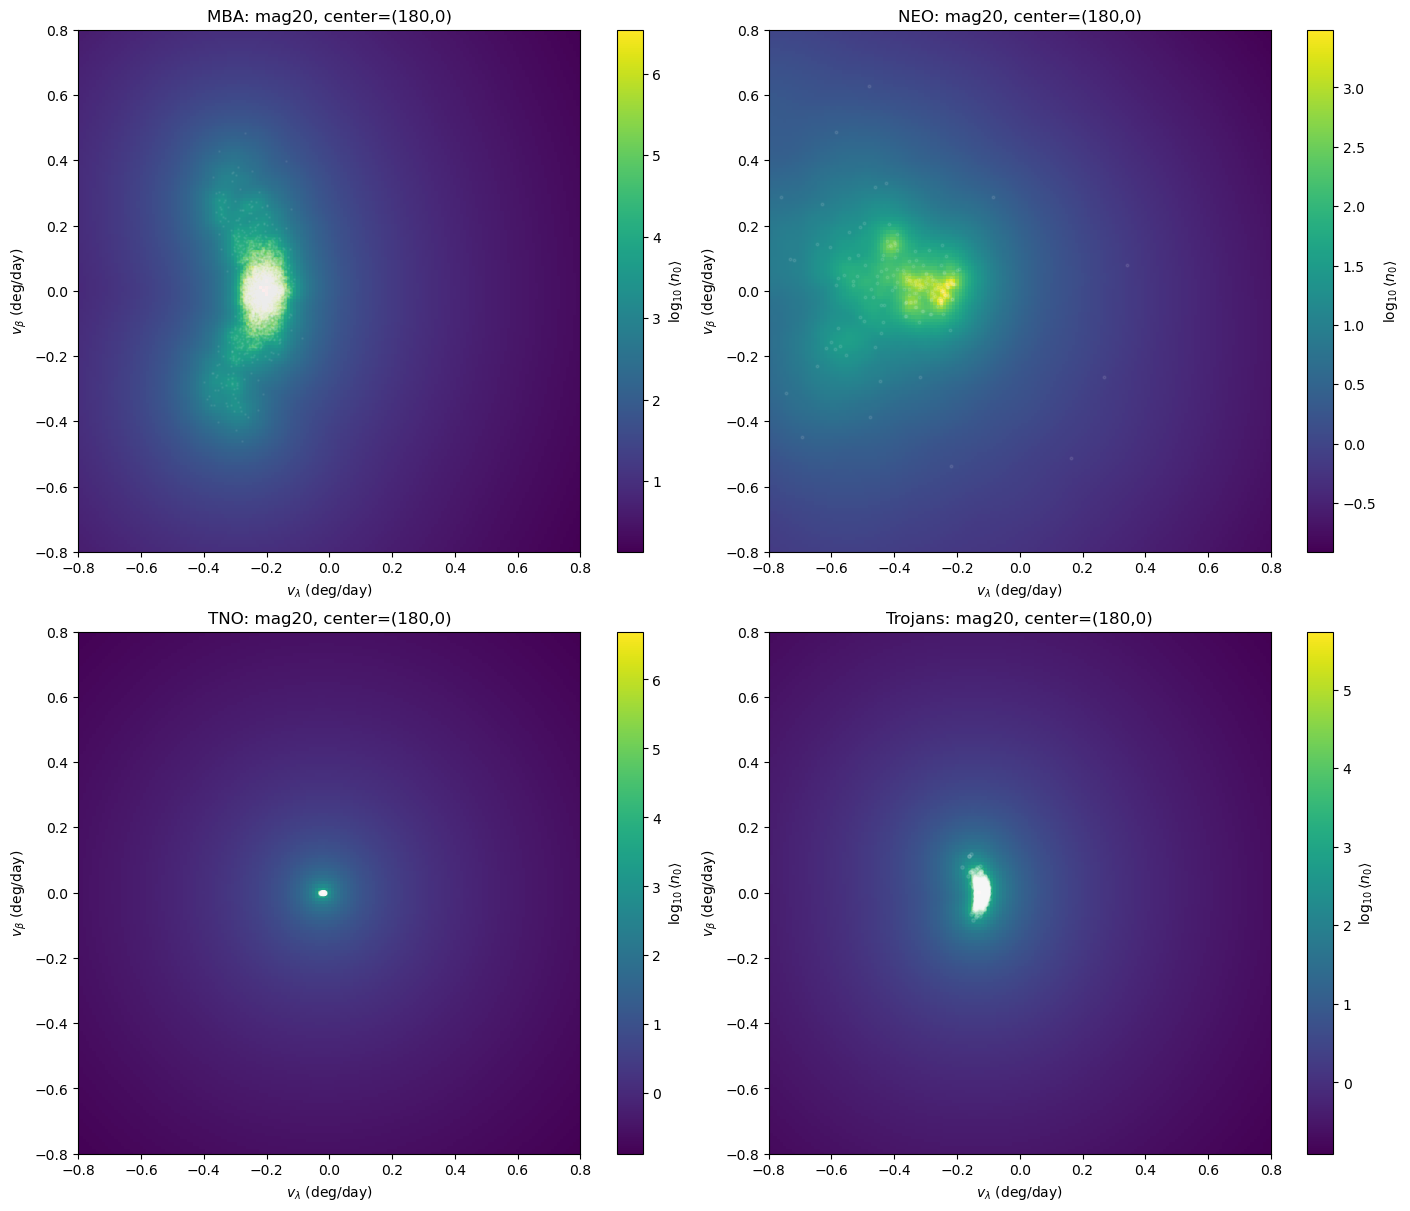

In [43]:
label = "mag20"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

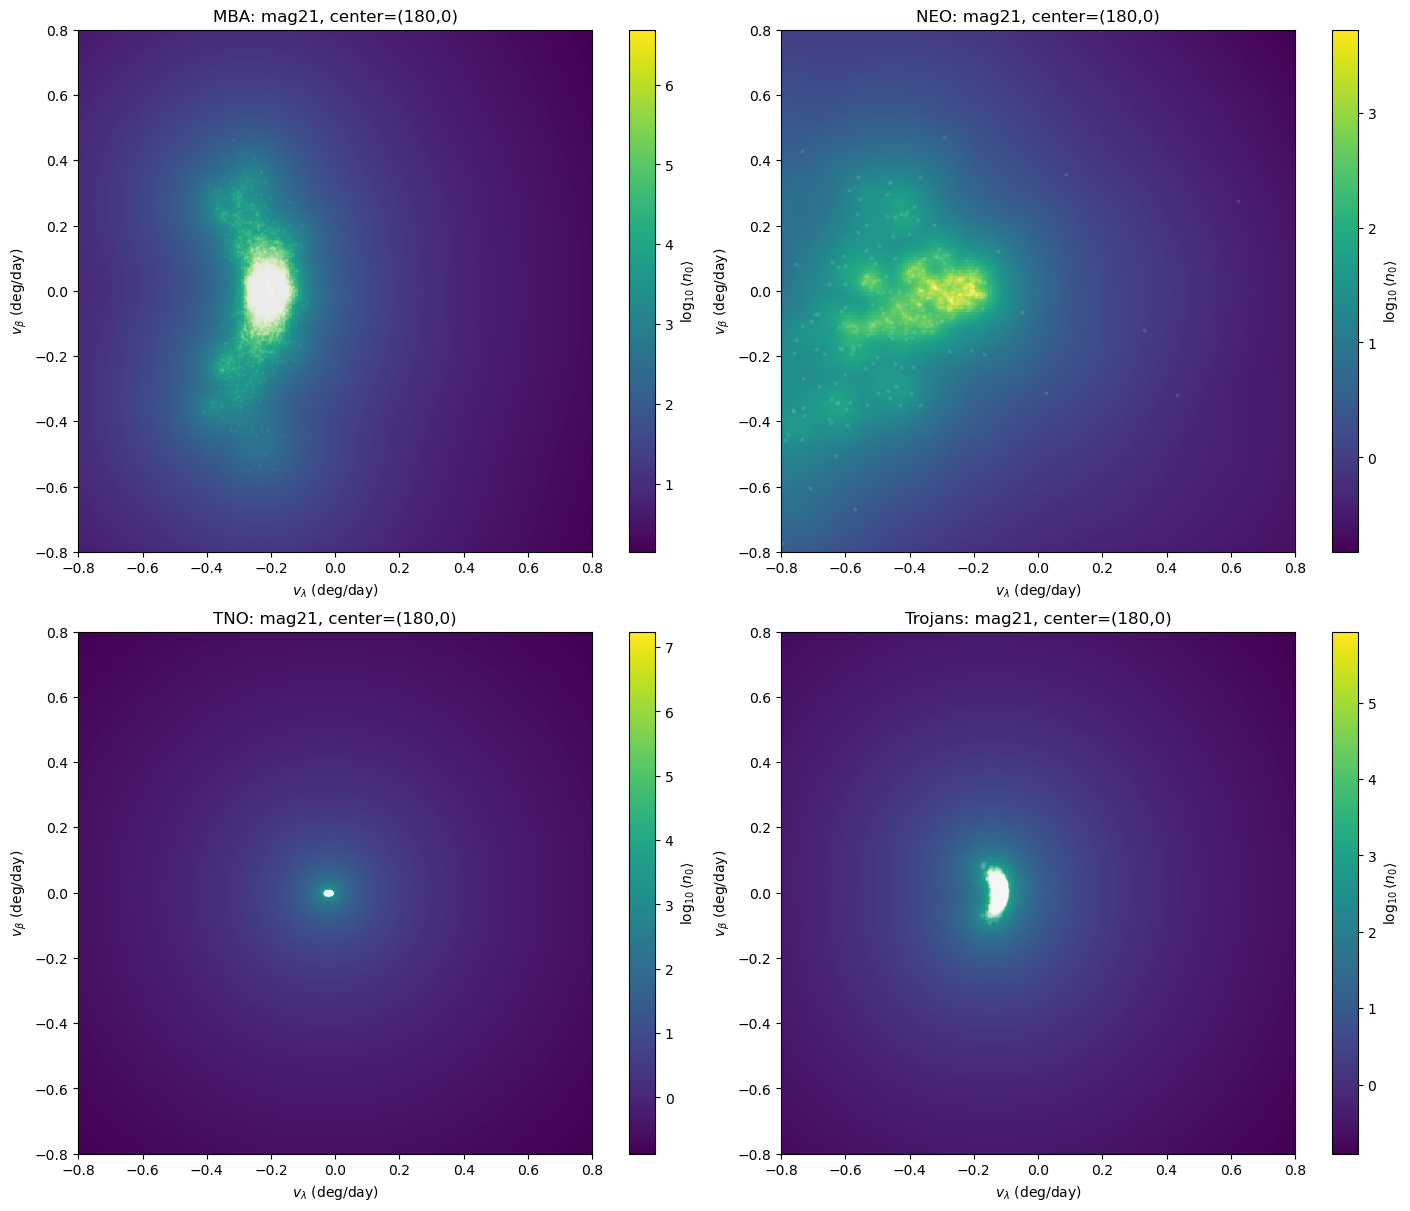

In [44]:
label = "mag21"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

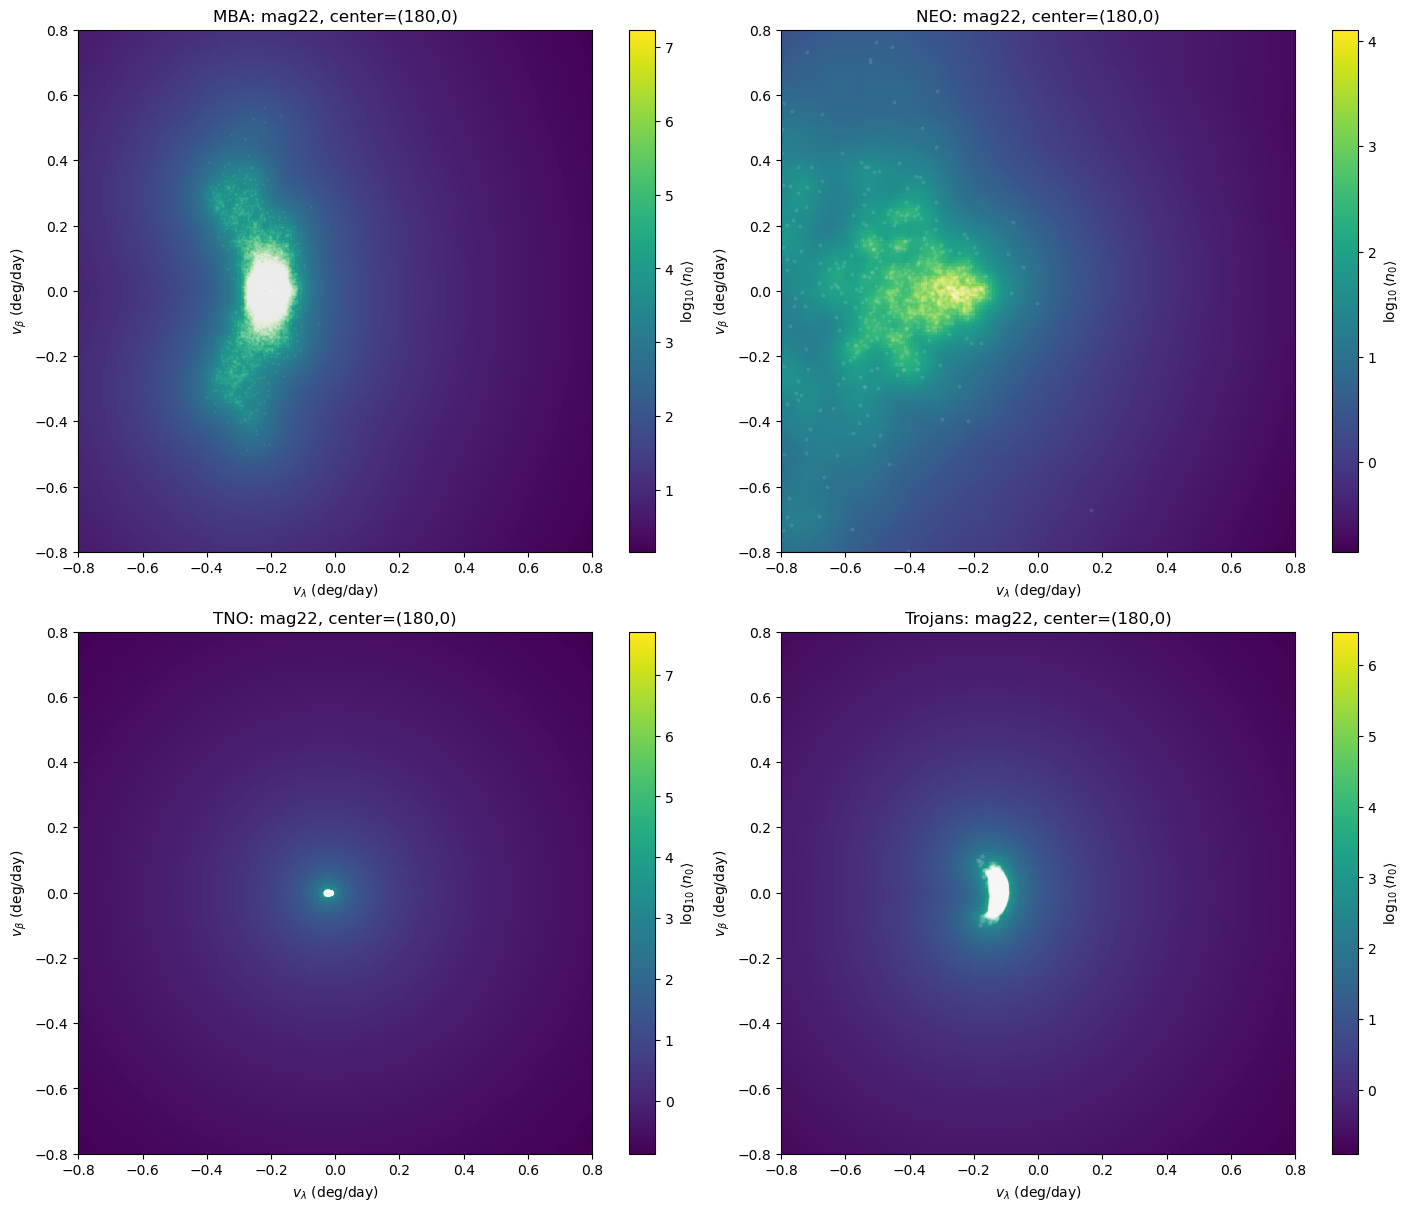

In [45]:
label = "mag22"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

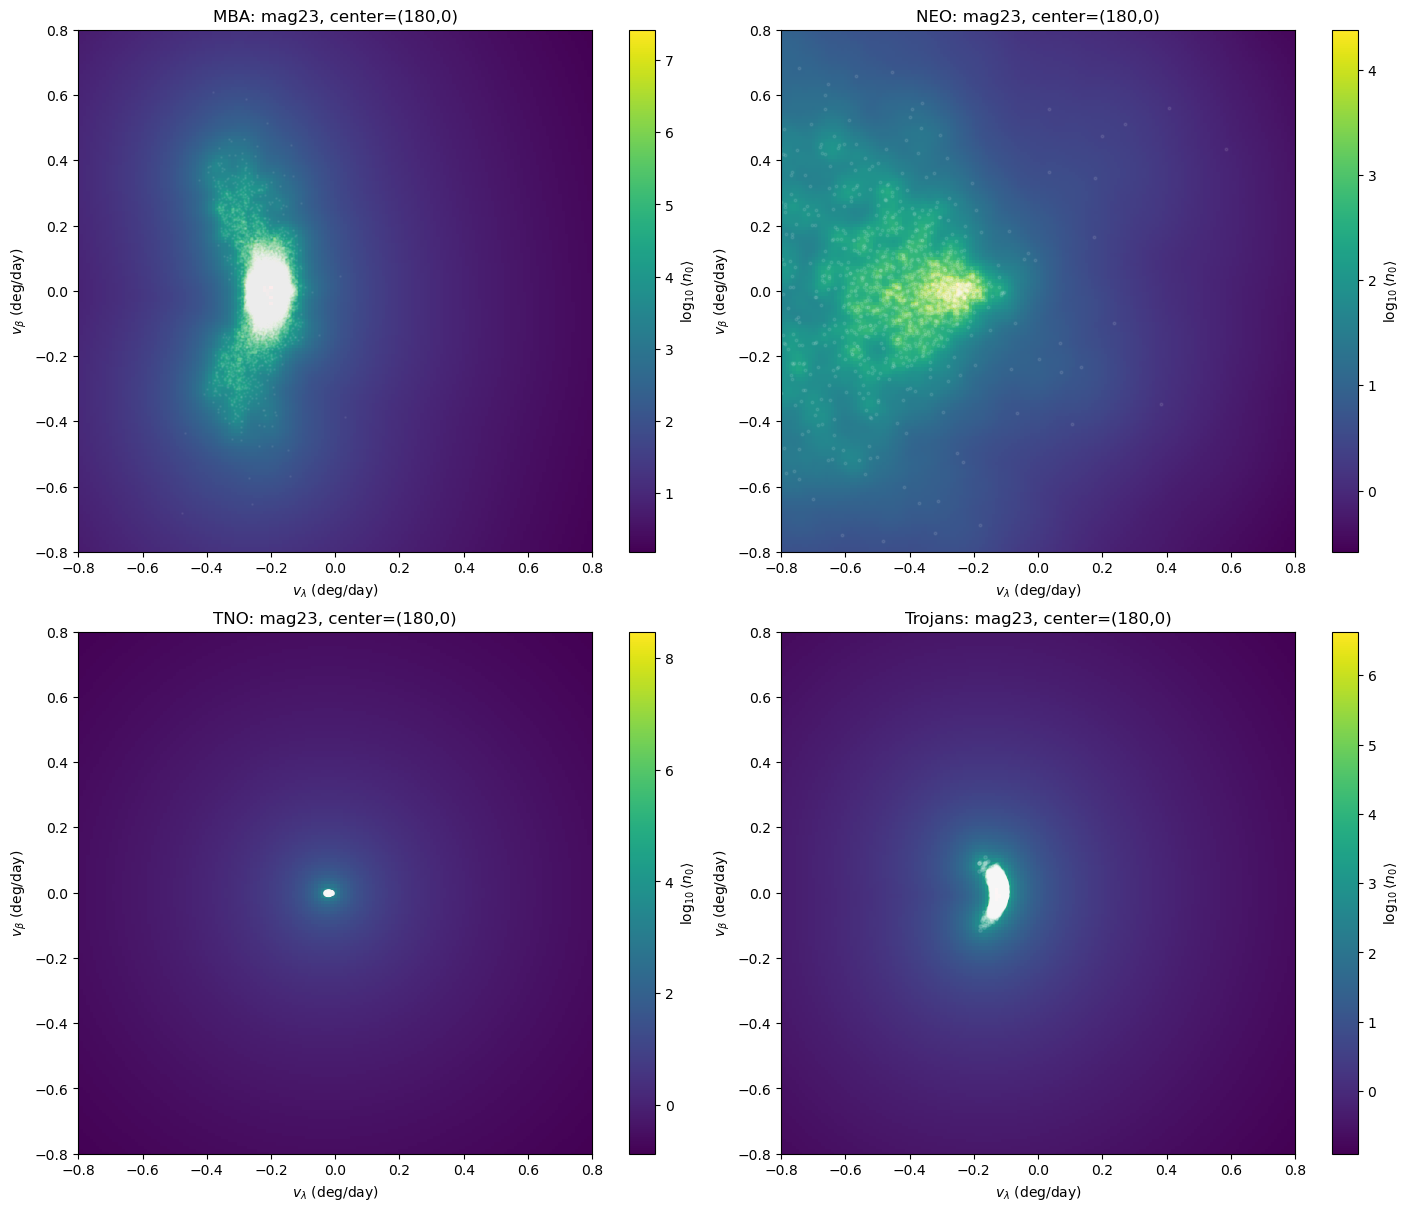

In [46]:
label = "mag23"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

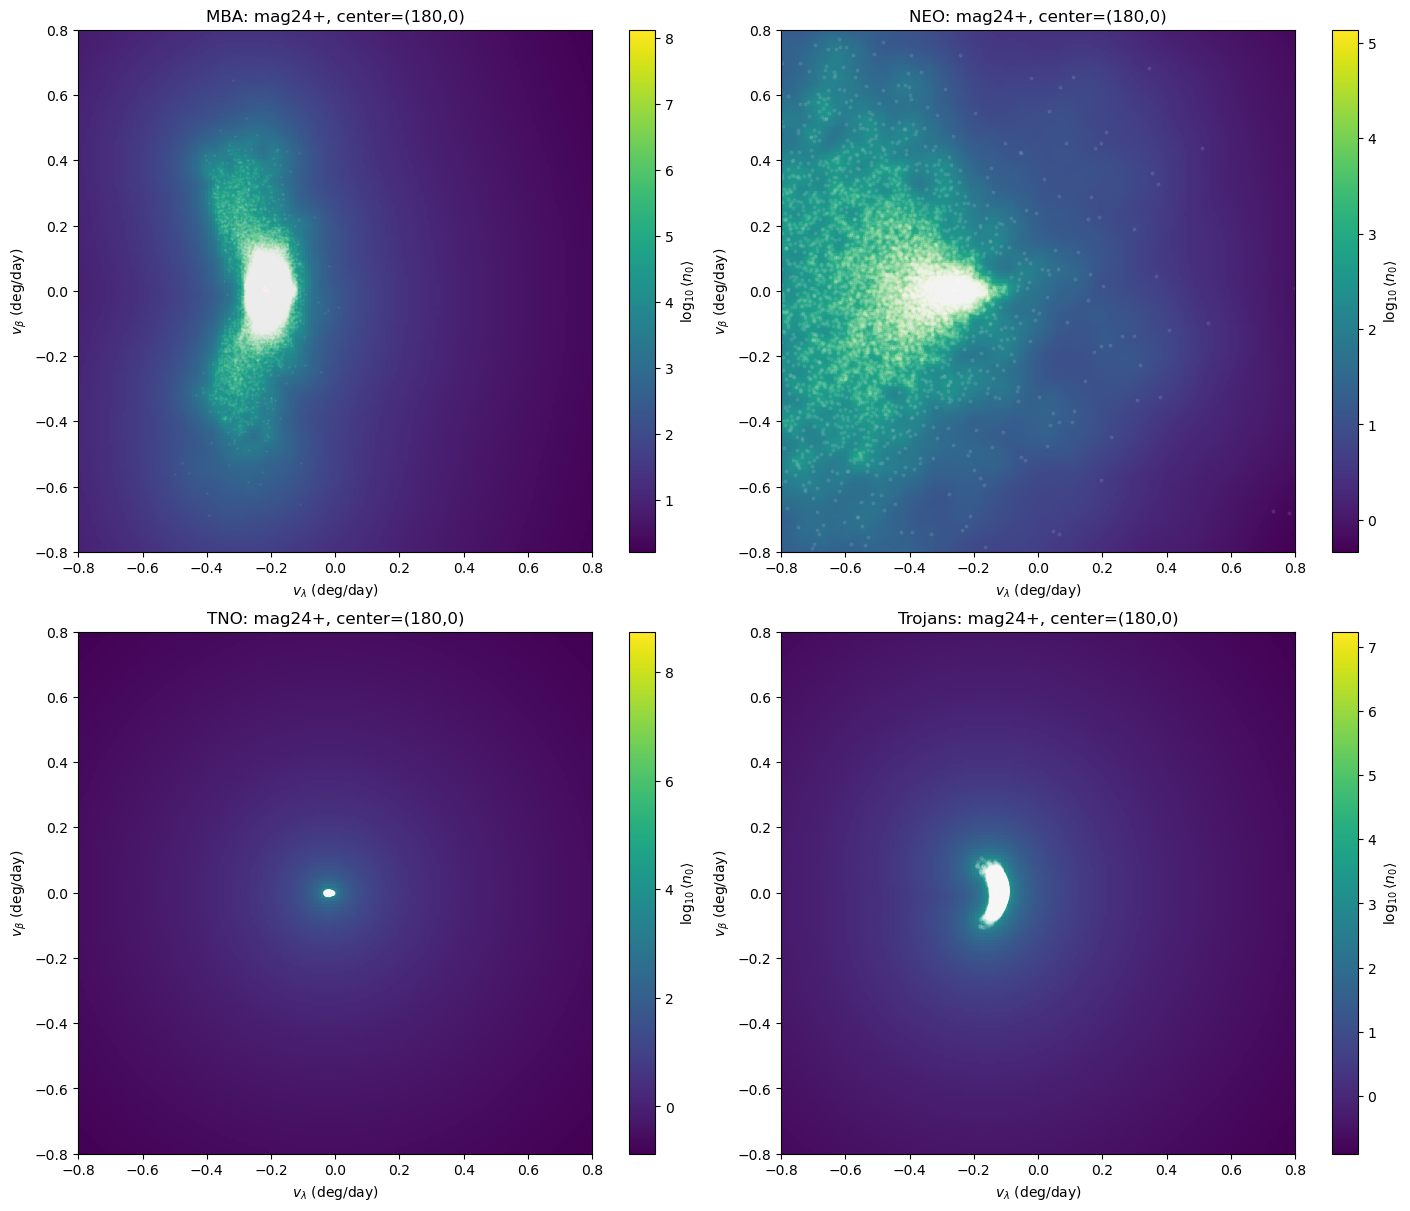

In [47]:
label = "mag24+"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [48]:
def elements_to_heliocentric_xy(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    chunk=100_000,
    show_progress=True,
    output_in_au=True,
):
    """
    Convert orbital elements to heliocentric ecliptic X,Y at obstime_str.
    Returns X, Y in AU (or km if output_in_au=False).
    """
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU, e=e, inc_deg=inc, raan_deg=raan,
        argp_deg=argp, tp_mjd=tp_mjd,
        obstime_str=obstime_str, method="newton",
        n_iter=10, chunk=chunk, show_progress=show_progress,
    )
    x = np.asarray(r_obj_ecl[:, 0], dtype=np.float64)
    y = np.asarray(r_obj_ecl[:, 1], dtype=np.float64)
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    if output_in_au:
        x = x / AU_km
        y = y / AU_km
    return x.astype(np.float32), y.astype(np.float32)

In [49]:
def plot_heliocentric_xy(x, y, title="Heliocentric ecliptic X-Y",
                         max_points=100_000, seed=123, xy_max_au=8.0):
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if len(x) > max_points:
        idx = rng.choice(len(x), size=max_points, replace=False)
        x, y = x[idx], y[idx]
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(x, y, s=2, alpha=0.35)
    ax.scatter([0], [0], s=80, marker="o")  # Sun
    ax.axhline(0, lw=1); ax.axvline(0, lw=1)
    ax.set_xlabel("Heliocentric ecliptic X (AU)")
    ax.set_ylabel("Heliocentric ecliptic Y (AU)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-xy_max_au, xy_max_au); ax.set_ylim(-xy_max_au, xy_max_au)
    plt.show()

def plot_xy_comparison(x1, y1, x2, y2, title1, title2,
                         xy_max_au=8.0, max_points=100_000, seed=123):
    rng = np.random.default_rng(seed)
    def sub(x, y):
        if len(x) > max_points:
            idx = rng.choice(len(x), size=max_points, replace=False)
            return x[idx], y[idx]
        return x, y
    x1, y1 = sub(np.asarray(x1), np.asarray(y1))
    x2, y2 = sub(np.asarray(x2), np.asarray(y2))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    for ax, x, y, title in [(ax1,x1,y1,title1),(ax2,x2,y2,title2)]:
        ax.scatter(x, y, s=2, alpha=0.35)
        ax.scatter([0], [0], s=80, marker="o")
        ax.axhline(0, lw=1); ax.axvline(0, lw=1)
        ax.set_xlabel("Heliocentric X (AU)"); ax.set_ylabel("Heliocentric Y (AU)")
        ax.set_title(title)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-xy_max_au, xy_max_au); ax.set_ylim(-xy_max_au, xy_max_au)
    plt.show()

Propagate with newton: 100%|██████████| 2/2 [00:00<00:00, 18.22it/s]


Visible Trojans in patch: 23605
M_obs range: 0.010989641358264635 359.9620525065643
L_obs range: 133.0863165391247 190.96715657394589


Propagate with newton: 100%|██████████| 2/2 [00:00<00:00, 21.13it/s]


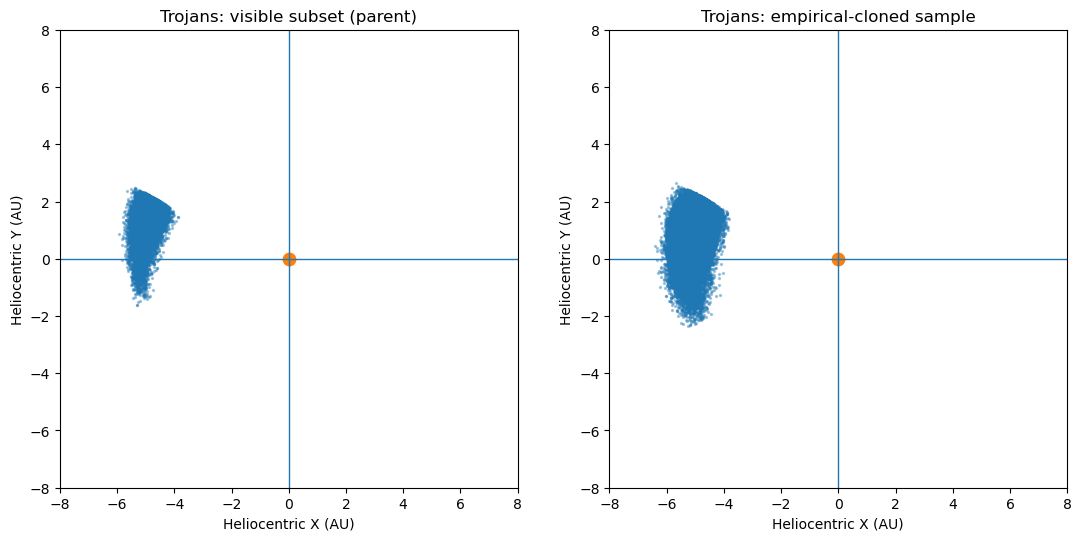

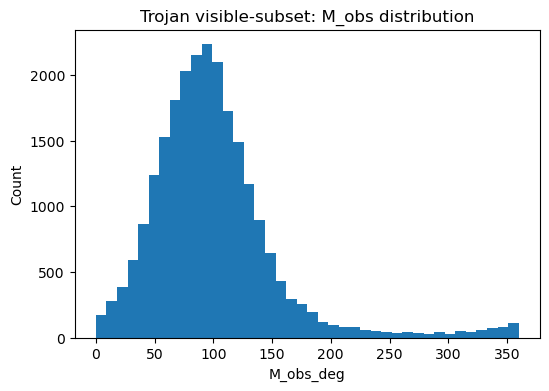

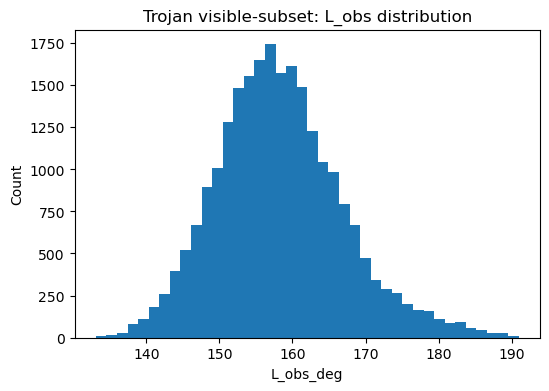

In [71]:
# get visible subset (sky-cut df)
trojan_visible = build_visible_subset_dataframe(
    trojan,                    # full raw trojan df
    obstime_str=obstime_str,
    scorer=scorer_tjn_s3m,
    max_sep_deg=max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
)
print("Visible Trojans in patch:", len(trojan_visible))
print("M_obs range:", trojan_visible["M_obs_deg"].min(), trojan_visible["M_obs_deg"].max())
print("L_obs range:", trojan_visible["L_obs_deg"].min(), trojan_visible["L_obs_deg"].max())
# heliocentric XY for the parent visible subset
x_vis, y_vis = elements_to_heliocentric_xy(
    trojan_visible["a"].to_numpy(), trojan_visible["e"].to_numpy(),
    trojan_visible["i"].to_numpy(), trojan_visible["node"].to_numpy(),
    trojan_visible["argperi"].to_numpy(), trojan_visible["t_p"].to_numpy(),
    obstime_str=obstime_str,
)

#  clone from visible_df using empirical longitude cloner
rng_xy = np.random.default_rng(701)

clone_visible_df = clone_population_conditional_K_from_M_with_skycut(
    df=trojan_visible,
    clone_factor=10,
    obstime_str=obstime_str,
    scorer=scorer_tjn_s3m,
    max_sep_deg=max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    rng=rng_xy,
)

x_clone, y_clone = elements_to_heliocentric_xy(
    clone_visible_df["a"].to_numpy(),
    clone_visible_df["e"].to_numpy(),
    clone_visible_df["i"].to_numpy(),
    clone_visible_df["node"].to_numpy(),
    clone_visible_df["argperi"].to_numpy(),
    clone_visible_df["t_p"].to_numpy(),
    obstime_str=obstime_str,
)

#  plot side by side
plot_xy_comparison(
    x_vis, y_vis,
    x_clone, y_clone,
    title1="Trojans: visible subset (parent)",
    title2="Trojans: empirical-cloned sample",
    xy_max_au=8.0,
    max_points=100_000,
    seed=703,
)

#  plot the M_obs phase distribution
plt.figure(figsize=(6, 4))
plt.hist(trojan_visible["M_obs_deg"], bins=40)
plt.xlabel("M_obs_deg"); plt.ylabel("Count")
plt.title("Trojan visible-subset: M_obs distribution")
plt.show()
# plot the L_obs phase distribution
plt.figure(figsize=(6, 4))
plt.hist(trojan_visible["L_obs_deg"], bins=40)
plt.xlabel("L_obs_deg"); plt.ylabel("Count")
plt.title("Trojan visible-subset: L_obs distribution")
plt.show()

In [72]:
print("Parent visible:", len(trojan_visible))
print("Clone visible:", len(clone_visible_df))

Parent visible: 23605
Clone visible: 185679


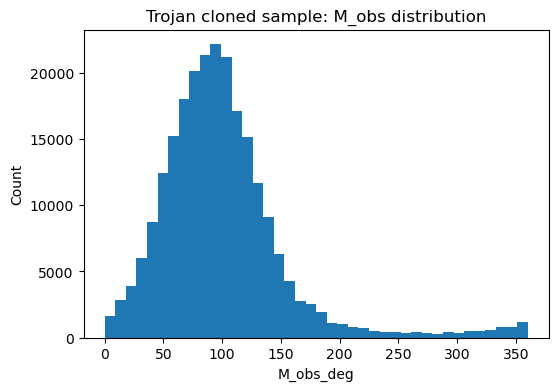

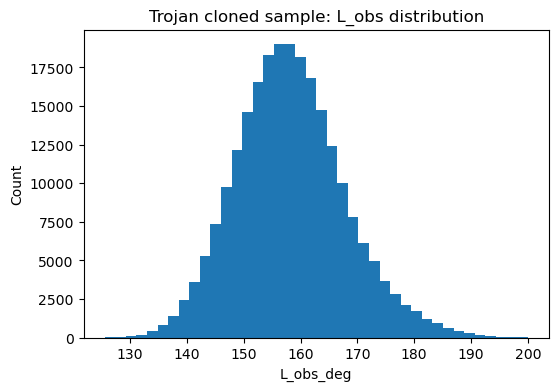

In [51]:
# cloned M_obs and L_obs at the same obstime
M_clone_deg = mean_anomaly_deg_at_obstime(
    a_rep,
    tp_new,
    obstime_str,
)

L_clone_deg = mean_longitude_deg_at_obstime(
    a_rep,
    raan_rep,
    argp_rep,
    tp_new,
    obstime_str,
)

# plot cloned M_obs histogram
plt.figure(figsize=(6, 4))
plt.hist(M_clone_deg, bins=40)
plt.xlabel("M_obs_deg")
plt.ylabel("Count")
plt.title("Trojan cloned sample: M_obs distribution")
plt.show()

# plot cloned L_obs histogram
plt.figure(figsize=(6, 4))
plt.hist(L_clone_deg, bins=40)
plt.xlabel("L_obs_deg")
plt.ylabel("Count")
plt.title("Trojan cloned sample: L_obs distribution")
plt.show()

Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 16.10it/s]


Parent visible: 23605
Clone visible after sky cut: 221863
Ratio (should be ~10): 9.398983266257149


Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 22.87it/s]


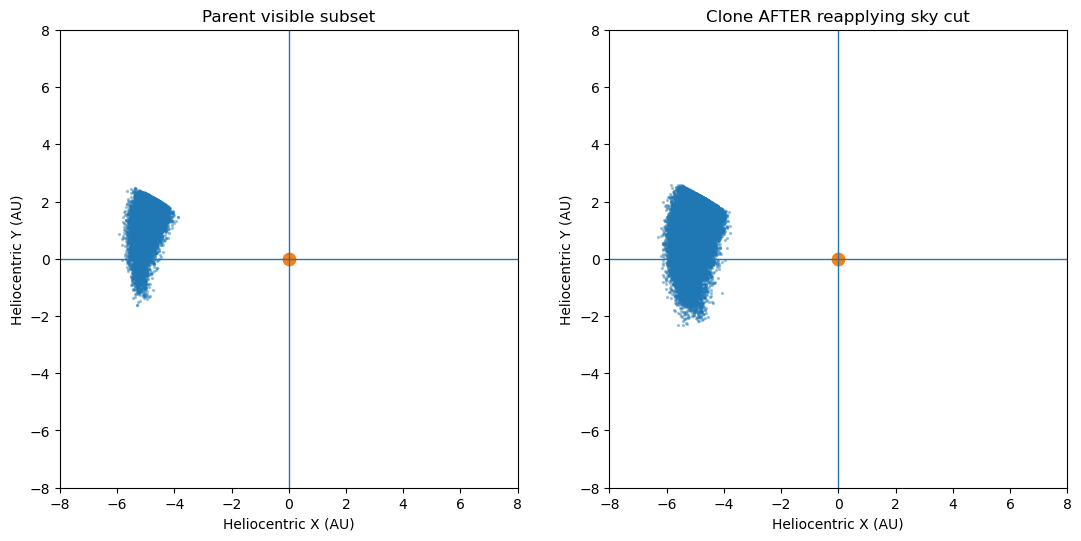

In [68]:
# second sky cut

clone_df = pd.DataFrame({
    "a":       pd.Series(a_rep.astype(np.float64)),
    "e":       pd.Series(e_rep.astype(np.float64)),
    "i":       pd.Series(inc_rep.astype(np.float64)),
    "node":    pd.Series(raan_rep.astype(np.float64)),
    "argperi": pd.Series(argp_rep.astype(np.float64)),  
    "t_p":     pd.Series(tp_new.astype(np.float64)),
    "H":       pd.Series(np.repeat(
                   trojan_visible["H"].to_numpy(dtype=np.float64), 10
               )),
})

clone_visible = build_visible_subset_dataframe(
    clone_df,
    obstime_str=obstime_str,
    scorer=scorer_tjn_s3m,
    max_sep_deg=max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
)

print("Parent visible:", len(trojan_visible))
print("Clone visible after sky cut:", len(clone_visible))
print("Ratio (should be ~10):", len(clone_visible) / len(trojan_visible))

# XY of sky-cut clones vs parent
x_clone_cut, y_clone_cut = elements_to_heliocentric_xy(
    clone_visible["a"].to_numpy(), clone_visible["e"].to_numpy(),
    clone_visible["i"].to_numpy(), clone_visible["node"].to_numpy(),
    clone_visible["argperi"].to_numpy(), clone_visible["t_p"].to_numpy(),
    obstime_str=obstime_str,
)

plot_xy_comparison(
    x_vis, y_vis,
    x_clone_cut, y_clone_cut,
    title1="Parent visible subset",
    title2="Clone AFTER reapplying sky cut",
)

In [70]:
clone_visible_df, clone_raw_df, diag = (
    clone_population_conditional_K_from_M_with_skycut(
        df=trojan_visible,
        clone_factor=10,
        obstime_str=obstime_str,
        scorer=scorer_tjn_s3m,
        max_sep_deg=max_sep_deg,
        center_mode="custom_ecliptic",
        center_lon_deg=180.0,
        center_lat_deg=0.0,
        rng=np.random.default_rng(701),
        return_raw_clone_df=True,
        return_diagnostics=True,
    )
)

Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 23.46it/s]


In [73]:
### trying to do this again but for all population

In [74]:
def run_population_clone_plot(
    df_full,
    scorer,
    pop_label,
    clone_func,
    clone_factor,
    obstime_str,
    max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    xy_max_au=8.0,
    rng_seed=701,
    plot_phase_hists=True,
):

    visible_df = build_visible_subset_dataframe(
        df_full,
        obstime_str=obstime_str,
        scorer=scorer,
        max_sep_deg=max_sep_deg,
        center_mode=center_mode,
        center_lon_deg=center_lon_deg,
        center_lat_deg=center_lat_deg,
    )

    print(f"{pop_label} visible in patch:", len(visible_df))
    print("M_obs range:", visible_df["M_obs_deg"].min(), visible_df["M_obs_deg"].max())
    print("L_obs range:", visible_df["L_obs_deg"].min(), visible_df["L_obs_deg"].max())

    x_vis, y_vis = elements_to_heliocentric_xy(
        visible_df["a"].to_numpy(),
        visible_df["e"].to_numpy(),
        visible_df["i"].to_numpy(),
        visible_df["node"].to_numpy(),
        visible_df["argperi"].to_numpy(),
        visible_df["t_p"].to_numpy(),
        obstime_str=obstime_str,
    )

    rng_xy = np.random.default_rng(rng_seed)

    clone_visible_df = clone_func(
        df=visible_df,
        clone_factor=clone_factor,
        obstime_str=obstime_str,
        scorer=scorer,
        max_sep_deg=max_sep_deg,
        center_mode=center_mode,
        center_lon_deg=center_lon_deg,
        center_lat_deg=center_lat_deg,
        rng=rng_xy,
    )

    print(f"{pop_label} clone visible:", len(clone_visible_df))

    x_clone, y_clone = elements_to_heliocentric_xy(
        clone_visible_df["a"].to_numpy(),
        clone_visible_df["e"].to_numpy(),
        clone_visible_df["i"].to_numpy(),
        clone_visible_df["node"].to_numpy(),
        clone_visible_df["argperi"].to_numpy(),
        clone_visible_df["t_p"].to_numpy(),
        obstime_str=obstime_str,
    )

    plot_xy_comparison(
        x_vis, y_vis,
        x_clone, y_clone,
        title1=f"{pop_label}: visible subset (parent)",
        title2=f"{pop_label}: empirical-cloned sample",
        xy_max_au=xy_max_au,
        max_points=100_000,
        seed=rng_seed + 2,
    )

    if plot_phase_hists:
        plt.figure(figsize=(6, 4))
        plt.hist(visible_df["M_obs_deg"], bins=40)
        plt.xlabel("M_obs_deg")
        plt.ylabel("Count")
        plt.title(f"{pop_label} visible-subset: M_obs distribution")
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(visible_df["L_obs_deg"], bins=40)
        plt.xlabel("L_obs_deg")
        plt.ylabel("Count")
        plt.title(f"{pop_label} visible-subset: L_obs distribution")
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(clone_visible_df["M_obs_deg"], bins=40)
        plt.xlabel("M_obs_deg")
        plt.ylabel("Count")
        plt.title(f"{pop_label} cloned-visible: M_obs distribution")
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(clone_visible_df["L_obs_deg"], bins=40)
        plt.xlabel("L_obs_deg")
        plt.ylabel("Count")
        plt.title(f"{pop_label} cloned-visible: L_obs distribution")
        plt.show()

    return visible_df, clone_visible_df

Propagate with newton: 100%|██████████| 2/2 [00:00<00:00, 17.91it/s]


Trojans visible in patch: 23605
M_obs range: 0.010989641358264635 359.9620525065643
L_obs range: 133.0863165391247 190.96715657394589


Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 24.59it/s]


Trojans clone visible: 185543


Propagate with newton: 100%|██████████| 2/2 [00:00<00:00, 20.83it/s]


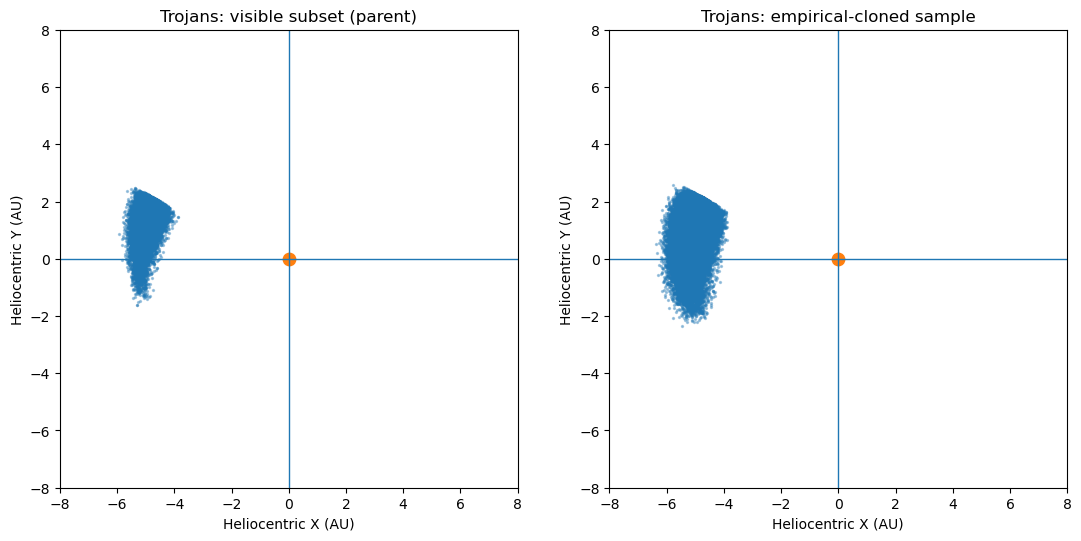

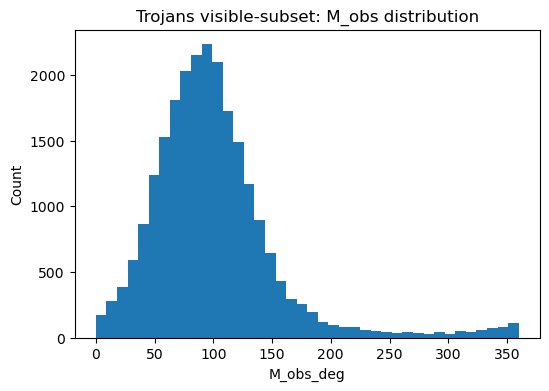

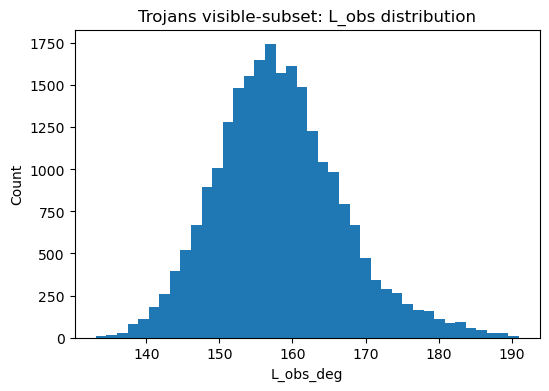

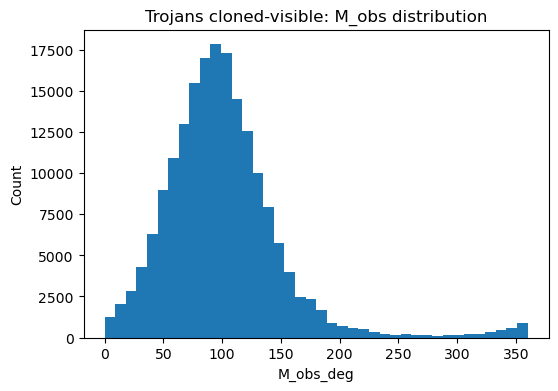

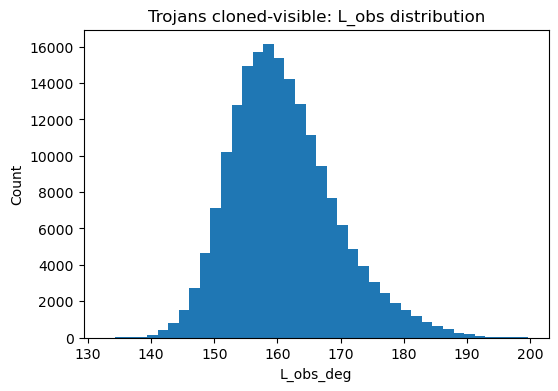

In [75]:
trojan_visible, trojan_clone_visible = run_population_clone_plot(
    df_full=trojan,
    scorer=scorer_tjn_s3m,
    pop_label="Trojans",
    clone_func=clone_population_conditional_K_from_M_with_skycut,
    clone_factor=10,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    xy_max_au=8.0,
    rng_seed=701,
)

In [ ]:
mba_visible, mba_clone_visible = run_population_clone_plot(
    df_full=s3m,
    scorer=scorer_mba_s3m,
    pop_label="MBAs",
    clone_func=clone_population_conditional_K_from_M_with_skycut,
    clone_factor=2,   
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    xy_max_au=8.0,
    rng_seed=701,
)

Propagate with newton: 100%|██████████| 139/139 [00:09<00:00, 15.01it/s]


MBAs visible in patch: 1410105
M_obs range: 0.000501309559240326 359.9997343832563
L_obs range: 92.51813099115083 253.14358941890544


Propagate with newton: 100%|██████████| 15/15 [00:00<00:00, 16.31it/s]


In [ ]:
neo_visible, neo_clone_visible = run_population_clone_plot(
    df_full=neo,
    scorer=scorer_neo_s3m,
    pop_label="NEOs",
    clone_func=clone_population_conditional_K_from_M_with_skycut,
    clone_factor=5,   
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    xy_max_au=8.0,
    rng_seed=702,
)

In [52]:
trojan_full_epoch = build_visible_subset_dataframe(
    trojan,
    obstime_str=obstime_str,
    scorer=scorer_tjn_s3m,
    max_sep_deg=180.0,              # effectively keep all
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
)

Propagate with newton: 100%|██████████| 2/2 [00:00<00:00, 18.23it/s]


In [53]:
trojan_bright = trojan_full_epoch[trojan_full_epoch["H"] < 11.5].copy()

In [55]:
a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_conditional_K_from_M(
    trojan_full_epoch,
    clone_factor=10,
    obstime_str=obstime_str,
    rng=np.random.default_rng(701),
)

In [56]:
M_clone_deg = mean_anomaly_deg_at_obstime(a_rep, tp_new, obstime_str)

L_clone_deg = mean_longitude_deg_at_obstime(
    a_rep, raan_rep, argp_rep, tp_new, obstime_str
)

In [57]:
from astropy.coordinates import (
    get_body_barycentric_posvel,
    SkyCoord,
    HeliocentricTrueEcliptic,
    CartesianRepresentation,
)
from astropy.time import Time
import astropy.units as u
import numpy as np

t = Time(obstime_str)

r_jup, _ = get_body_barycentric_posvel("jupiter", t)

jup_icrs = SkyCoord(
    CartesianRepresentation(r_jup.x, r_jup.y, r_jup.z),
    frame="icrs",
    obstime=t,
)

jup_ecl = jup_icrs.transform_to(HeliocentricTrueEcliptic(obstime=t))

L_jupiter_deg = jup_ecl.lon.deg % 360.0
print("L_jupiter_deg =", L_jupiter_deg)

L_jupiter_deg = 84.83682466731966


In [58]:
L_known_rot  = (trojan_full_epoch["L_obs_deg"] - L_jupiter_deg) % 360
L_bright_rot = (trojan_bright["L_obs_deg"] - L_jupiter_deg) % 360
L_clone_rot  = (L_clone_deg - L_jupiter_deg) % 360

In [59]:
import matplotlib.pyplot as plt
import numpy as np

def plot_s3m_style_trojan_distributions(
    L_known_deg,
    L_bright_deg,
    L_syn_deg,
    M_known_deg,
    M_bright_deg,
    M_syn_deg,
    node_known_deg,
    node_bright_deg,
    node_syn_deg,
    argp_known_deg,
    argp_bright_deg,
    argp_syn_deg,
    bins_L=np.linspace(-180, 180, 37),
    bins_360=np.linspace(0, 360, 37),
):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    
    L_known  = ((np.asarray(L_known_deg)  + 180) % 360) - 180
    L_bright = ((np.asarray(L_bright_deg) + 180) % 360) - 180
    L_syn    = ((np.asarray(L_syn_deg)    + 180) % 360) - 180
    
    M_known  = np.asarray(M_known_deg)
    M_bright = np.asarray(M_bright_deg)
    M_syn    = np.asarray(M_syn_deg)
    
    node_known  = np.asarray(node_known_deg)
    node_bright = np.asarray(node_bright_deg)
    node_syn    = np.asarray(node_syn_deg)
    
    argp_known  = np.asarray(argp_known_deg)
    argp_bright = np.asarray(argp_bright_deg)
    argp_syn    = np.asarray(argp_syn_deg)
    panels = [
        (axes[0, 0], L_known, L_bright, L_syn, bins_L, "Mean longitude [°]"),
        (axes[0, 1], M_known, M_bright, M_syn, bins_360, "Mean anomaly [°]"),
        (axes[1, 0], node_known, node_bright, node_syn, bins_360, "Longitude of Ascending Node [°]"),
        (axes[1, 1], argp_known, argp_bright, argp_syn, bins_360, "Argument of Perihelion [°]"),
    ]

    for ax, known, bright, syn, bins, xlabel in panels:
        ax.hist(bright, bins=bins, density=True, histtype="step",
                color="0.7", linewidth=2, label="Known, H < 11.5")
        ax.hist(known, bins=bins, density=True, histtype="step",
                color="k", linewidth=2, label="Known")
        ax.hist(syn, bins=bins, density=True, histtype="step",
                color="k", linestyle="--", linewidth=2, label="Synthetic")

        ax.set_xlabel(xlabel)
        ax.set_ylabel("Normalized fraction")

    axes[0, 1].legend(frameon=True)
    fig.suptitle("Jovian Trojan Population", fontsize=20)
    plt.tight_layout()
    plt.show()

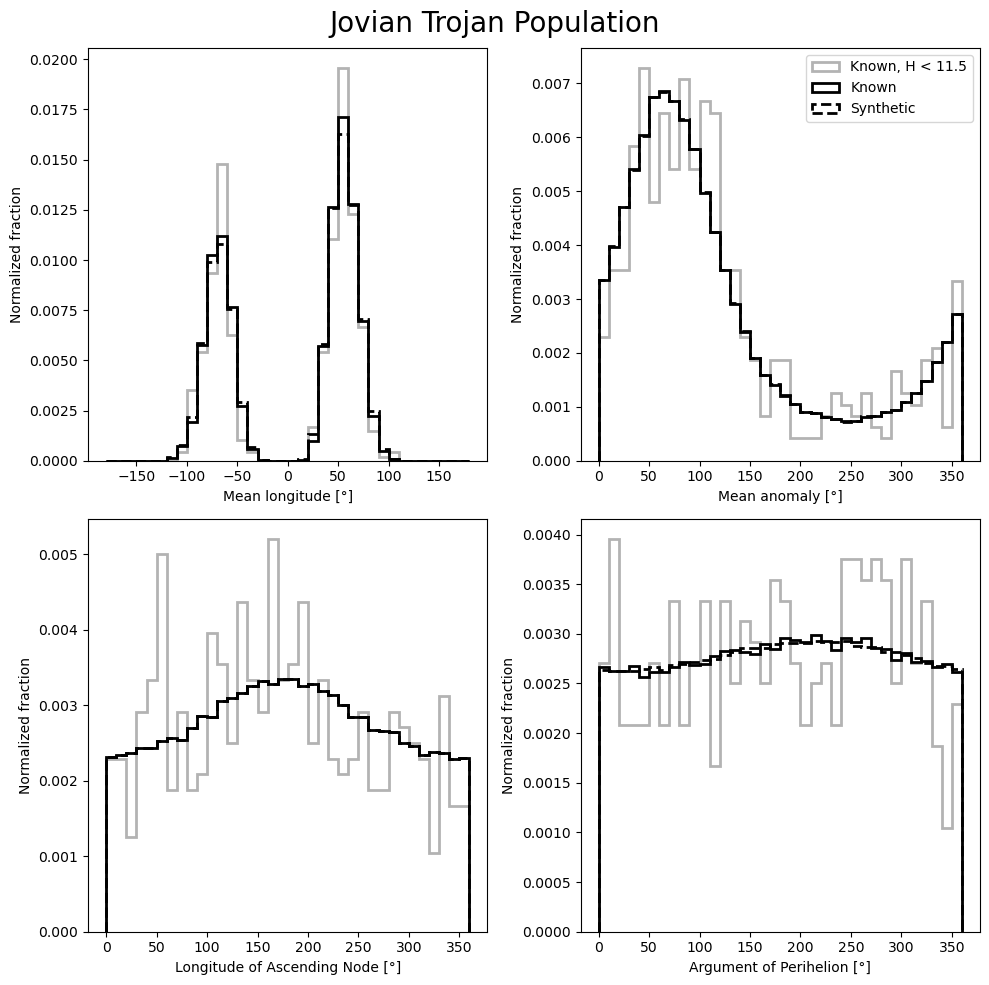

In [60]:
plot_s3m_style_trojan_distributions(
    L_known_deg=L_known_rot,
    L_bright_deg=L_bright_rot,
    L_syn_deg=L_clone_rot,

    M_known_deg=trojan_full_epoch["M_obs_deg"],
    M_bright_deg=trojan_bright["M_obs_deg"],
    M_syn_deg=M_clone_deg,

    node_known_deg=trojan_full_epoch["node"],
    node_bright_deg=trojan_bright["node"],
    node_syn_deg=raan_rep,

    argp_known_deg=trojan_full_epoch["argperi"],
    argp_bright_deg=trojan_bright["argperi"],
    argp_syn_deg=argp_rep,
)

mean_angle (deg): 91.04564687575045
M_shift min (deg): 0.001724334865778619
M_shift max (deg): 359.99980519012837
M_shift range (deg): 359.9980808552626


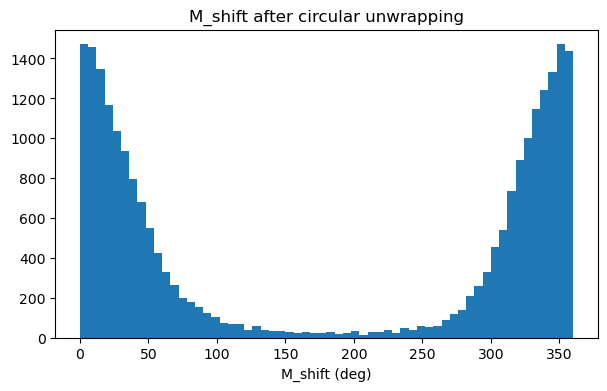

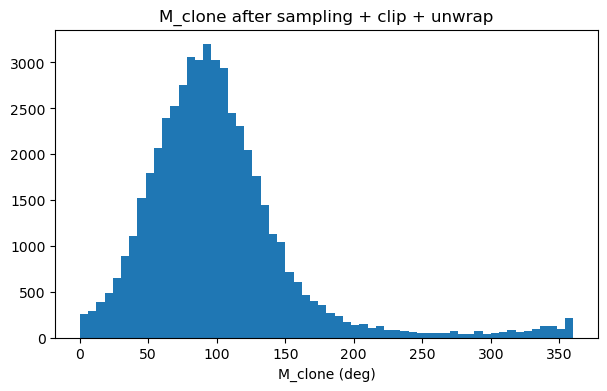

In [61]:


t_obs = Time(obstime_str, scale="tdb")
tp = trojan_visible["t_p"].to_numpy(dtype=np.float64)
a_AU = trojan_visible["a"].to_numpy(dtype=np.float64)
a_km = a_AU * AU_km
n_rad_s = np.sqrt(mu_sun / (a_km**3))
n_rad_day = n_rad_s * 86400.0

M_obs = np.mod((t_obs.mjd - tp) * n_rad_day, 2.0 * np.pi)
mean_angle = np.angle(np.mean(np.exp(1j * M_obs)))
M_shift = np.mod(M_obs - mean_angle, 2.0 * np.pi)

print("mean_angle (deg):", np.rad2deg(mean_angle))
print("M_shift min (deg):", np.rad2deg(M_shift.min()))
print("M_shift max (deg):", np.rad2deg(M_shift.max()))
print("M_shift range (deg):", np.rad2deg(M_shift.max() - M_shift.min()))

# plot M_shift
plt.figure(figsize=(7, 4))
plt.hist(np.rad2deg(M_shift), bins=60)
plt.xlabel("M_shift (deg)")
plt.title("M_shift after circular unwrapping")
plt.show()

# now simulate what EmpiricalDistribution samples
from astroML.density_estimation import EmpiricalDistribution
rng_test = np.random.default_rng(42)
M_shift_clone = EmpiricalDistribution(M_shift).rvs(50000)
M_shift_clone_clipped = np.clip(M_shift_clone, M_shift.min(), M_shift.max())
M_clone = np.mod(M_shift_clone_clipped + mean_angle, 2.0 * np.pi)

plt.figure(figsize=(7, 4))
plt.hist(np.rad2deg(M_clone), bins=60)
plt.xlabel("M_clone (deg)")
plt.title("M_clone after sampling + clip + unwrap")
plt.show()

In [63]:
def elements_to_eclipticstrip_quantities_chunk(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str, scorer, beta_max_deg=3.0, rate_chunk=100_000,
):
    """Propagate elements -> ecliptic lambda, beta, vlam, vbeta filtered by beta < beta_max_deg."""
    t_obs = Time(obstime_str, scale="tdb")
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU, e=e, inc_deg=inc, raan_deg=raan, argp_deg=argp,
        tp_mjd=tp_mjd, obstime_str=obstime_str,
        method="newton", n_iter=10, chunk=rate_chunk, show_progress=False,
    )
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)
    r_eq = np.column_stack([r_obj_ecl[:,0], c*r_obj_ecl[:,1]-s*r_obj_ecl[:,2], s*r_obj_ecl[:,1]+c*r_obj_ecl[:,2]])
    v_eq = np.column_stack([v_obj_ecl[:,0], c*v_obj_ecl[:,1]-s*v_obj_ecl[:,2], s*v_obj_ecl[:,1]+c*v_obj_ecl[:,2]])
    del r_obj_ecl, v_obj_ecl
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)
    r_rel = r_eq - (rE + r_tele)
    v_rel = v_eq - vE
    del r_eq, v_eq
    x,y,z = r_rel[:,0], r_rel[:,1], r_rel[:,2]
    vx,vy,vz = v_rel[:,0], v_rel[:,1], v_rel[:,2]
    rho2 = x*x+y*y; r2 = rho2+z*z; rho = np.sqrt(rho2)
    ra = np.arctan2(y,x); dec = np.arctan2(z,rho)
    dra = (x*vy-y*vx)/rho2
    ddec = (vz*rho2-z*(x*vx+y*vy))/(r2*rho)
    good = (np.isfinite(ra)&np.isfinite(dec)&np.isfinite(dra)&np.isfinite(ddec)&
            np.isfinite(rho2)&np.isfinite(r2)&(rho2>0)&(r2>0))
    ra_deg = (np.rad2deg(ra[good])%360.0).astype(np.float32)
    dec_deg = np.rad2deg(dec[good]).astype(np.float32)
    dra_d = (np.rad2deg(dra[good])*86400.0).astype(np.float32)
    ddec_d = (np.rad2deg(ddec[good])*86400.0).astype(np.float32)
    del r_rel, v_rel, x,y,z,vx,vy,vz,rho2,r2,rho,ra,dec,dra,ddec,good
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
    ecl = sc.transform_to(GeocentricTrueEcliptic(obstime=t_obs))
    lam_deg = (ecl.lon.to_value(u.deg)%360.0).astype(np.float32)
    beta_deg = ecl.lat.to_value(u.deg).astype(np.float32)
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(ra_deg, dec_deg, dra_d, ddec_d, obstime_str)
    vlam = np.asarray(vlam, dtype=np.float32)
    vbeta = np.asarray(vbeta, dtype=np.float32)
    m = np.abs(beta_deg) <= beta_max_deg
    return lam_deg[m], beta_deg[m], vlam[m], vbeta[m]

def build_eclipticstrip_for_population_chunked(
    df, scorer, clone_factor, obstime_str,
    beta_max_deg=3.0, object_chunk=50_000, rate_chunk=100_000,
    rng=None, verbose=True,
):
    """Clone full population with uniform M in chunks -> ecliptic strip quantities."""
    if rng is None: rng = np.random.default_rng(42)
    n_obj = len(df)
    lam_list, beta_list, vlam_list, vbeta_list = [], [], [], []
    for i0 in range(0, n_obj, object_chunk):
        i1 = min(i0+object_chunk, n_obj)
        if verbose: print(f"  Objects {i0:,} to {i1:,} of {n_obj:,}")
        df_chunk = df.iloc[i0:i1]
        a_rep,e_rep,inc_rep,raan_rep,argp_rep,tp_use = clone_population_conditional_K_from_M(
            df_chunk, clone_factor=clone_factor, obstime_str=obstime_str, rng=rng,
        )
        lam,beta,vlam,vbeta = elements_to_eclipticstrip_quantities_chunk(
            a_rep,e_rep,inc_rep,raan_rep,argp_rep,tp_use,
            obstime_str=obstime_str, scorer=scorer,
            beta_max_deg=beta_max_deg, rate_chunk=rate_chunk,
        )
        lam_list.append(lam); beta_list.append(beta)
        vlam_list.append(vlam); vbeta_list.append(vbeta)
        del a_rep,e_rep,inc_rep,raan_rep,argp_rep,tp_use,lam,beta,vlam,vbeta
        gc.collect()
    cat = lambda lst: np.concatenate(lst).astype(np.float32) if lst else np.array([], dtype=np.float32)
    return {"lam_deg":cat(lam_list), "beta_deg":cat(beta_list),
            "vlam":cat(vlam_list), "vbeta":cat(vbeta_list)}

In [64]:
def plot_eclipticstrip_populations(
    population_data, populations=None,
    beta_max_deg=3.0, lam_window=(0.0, 360.0),
    beta_ylim=(-10,10), vlam_ylim=(-0.8,0.8), vbeta_ylim=(-0.3,0.3),
    max_points=None, seed=123, title="Ecliptic-strip plot",
):
    rng = np.random.default_rng(seed)
    if populations is None: populations = list(population_data.keys())
    if max_points is None: max_points = {p:100_000 for p in populations}
    style_map = {
        "MBA":    {"alpha":0.22,"s":1,"color":"orange"},
        "NEO":    {"alpha":0.08,"s":1,"color":"blue"},
        "TNO":    {"alpha":0.18,"s":1,"color":"green"},
        "Trojans":{"alpha":0.18,"s":1,"color":"purple"},
    }
    prepared = {}
    for pop in populations:
        data = population_data[pop]
        lam = np.mod(data["lam_deg"], 360.0)
        beta, vlam, vbeta = data["beta_deg"], data["vlam"], data["vbeta"]
        lo, hi = lam_window
        m = (lam>=lo)&(lam<=hi) if lo<=hi else (lam>=lo)|(lam<=hi)
        lam,beta,vlam,vbeta = lam[m],beta[m],vlam[m],vbeta[m]
        nmax = max_points.get(pop, len(lam))
        if len(lam)>nmax:
            idx=rng.choice(len(lam),size=nmax,replace=False)
            lam,beta,vlam,vbeta=lam[idx],beta[idx],vlam[idx],vbeta[idx]
        prepared[pop]={"lam":lam,"beta":beta,"vlam":vlam,"vbeta":vbeta}
        print(f"{pop} in window: {len(lam)}")
    fig,(ax1,ax2,ax3)=plt.subplots(3,1,figsize=(9,10),sharex=True,
        gridspec_kw=dict(height_ratios=[1.1,1.0,1.0],hspace=0.12))
    for pop in populations:
        st=style_map.get(pop,{"alpha":0.18,"s":1}); d=prepared[pop]
        ax1.scatter(d["lam"],d["beta"],s=st["s"],alpha=st["alpha"],color=st["color"],label=pop)
        ax2.scatter(d["lam"],d["vlam"],s=st["s"],alpha=st["alpha"],color=st["color"])
        ax3.scatter(d["lam"],d["vbeta"],s=st["s"],alpha=st["alpha"],color=st["color"])
    ax1.axhline(0,lw=1); ax1.set_ylabel(r"$\beta$ (deg)"); ax1.set_ylim(*beta_ylim); ax1.legend(loc="upper right")
    ax2.axhline(0,lw=1); ax2.set_ylabel(r"$v_\lambda$ (deg/day)"); ax2.set_ylim(*vlam_ylim)
    ax3.axhline(0,lw=1); ax3.set_ylabel(r"$v_\beta$ (deg/day)"); ax3.set_xlabel(r"$\lambda$ (deg)"); ax3.set_ylim(*vbeta_ylim)
    ax3.set_xlim(360,0)
    fig.suptitle(title+f"\nwith |β| < {beta_max_deg}°")
    plt.show()

  Objects 0 to 20,000 of 13,883,361
  Objects 20,000 to 40,000 of 13,883,361
  Objects 40,000 to 60,000 of 13,883,361
  Objects 60,000 to 80,000 of 13,883,361
  Objects 80,000 to 100,000 of 13,883,361
  Objects 100,000 to 120,000 of 13,883,361
  Objects 120,000 to 140,000 of 13,883,361
  Objects 140,000 to 160,000 of 13,883,361
  Objects 160,000 to 180,000 of 13,883,361
  Objects 180,000 to 200,000 of 13,883,361
  Objects 200,000 to 220,000 of 13,883,361
  Objects 220,000 to 240,000 of 13,883,361
  Objects 240,000 to 260,000 of 13,883,361
  Objects 260,000 to 280,000 of 13,883,361
  Objects 280,000 to 300,000 of 13,883,361
  Objects 300,000 to 320,000 of 13,883,361
  Objects 320,000 to 340,000 of 13,883,361
  Objects 340,000 to 360,000 of 13,883,361
  Objects 360,000 to 380,000 of 13,883,361
  Objects 380,000 to 400,000 of 13,883,361
  Objects 400,000 to 420,000 of 13,883,361
  Objects 420,000 to 440,000 of 13,883,361
  Objects 440,000 to 460,000 of 13,883,361
  Objects 460,000 to 480,

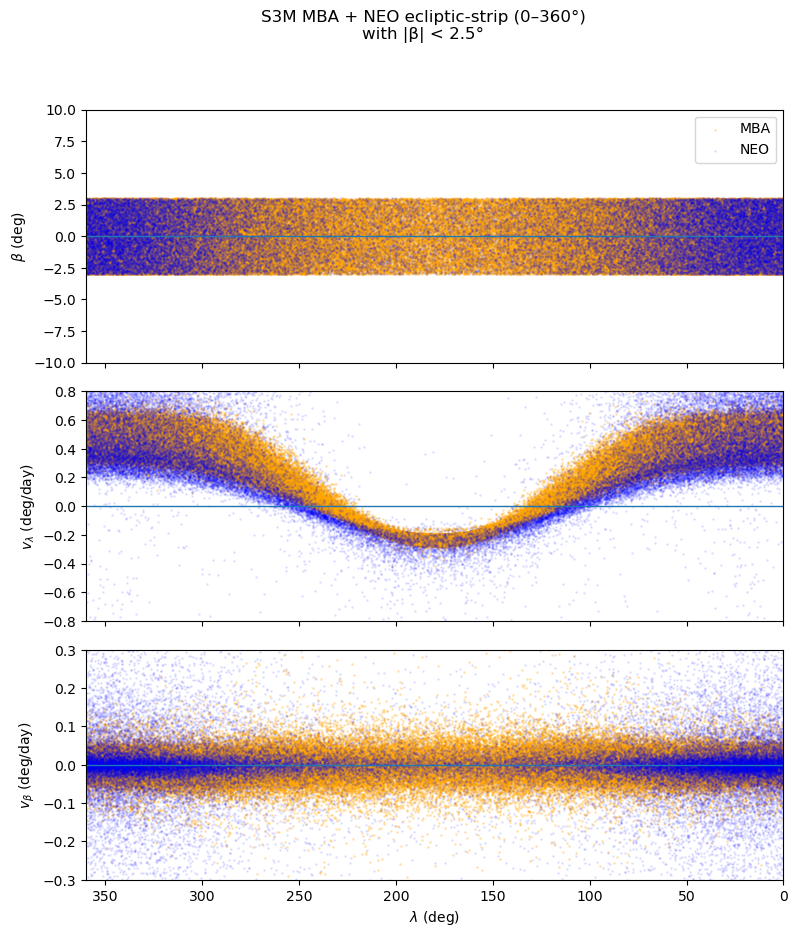

Trojans in window: 100000


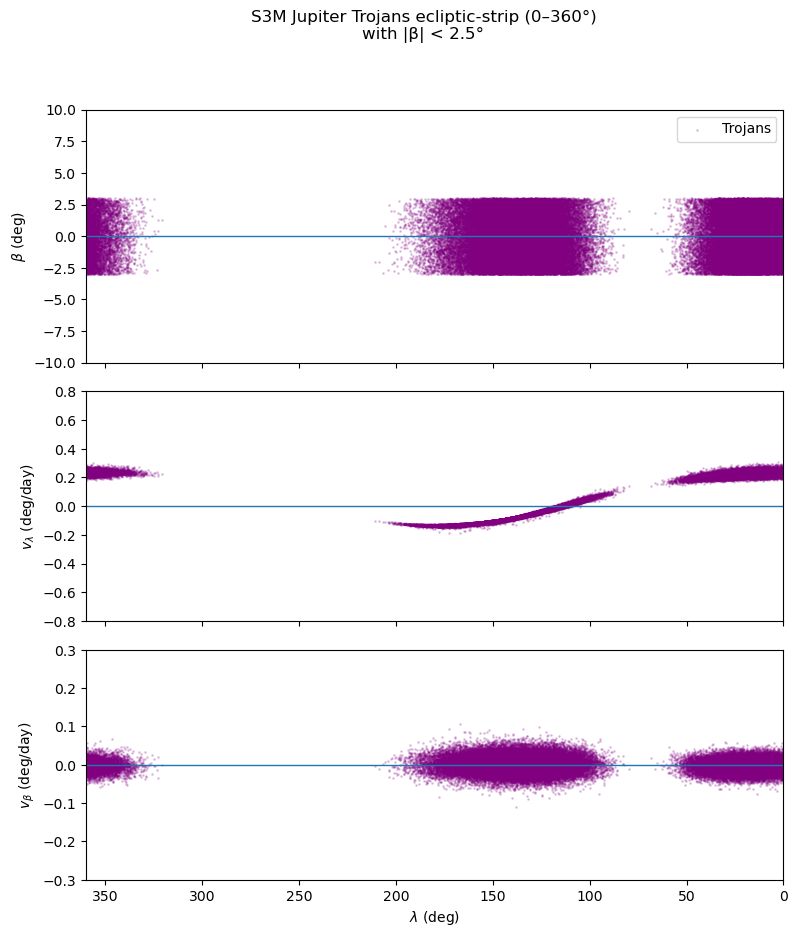

In [65]:
# Build strip data for each population
fig5_mba_ecliptic = build_eclipticstrip_for_population_chunked(
    df=clone_sources["MBA"]["df"], scorer=clone_sources["MBA"]["scorer"],
    clone_factor=clone_sources["MBA"]["clone_factor"],
    obstime_str=obstime_str, beta_max_deg=3.0,
    object_chunk=20_000, rate_chunk=50_000,
    rng=np.random.default_rng(501), verbose=True,
)

fig5_neo_ecliptic = build_eclipticstrip_for_population_chunked(
    df=clone_sources["NEO"]["df"], scorer=clone_sources["NEO"]["scorer"],
    clone_factor=clone_sources["NEO"]["clone_factor"],
    obstime_str=obstime_str, beta_max_deg=3.0,
    object_chunk=20_000, rate_chunk=50_000,
    rng=np.random.default_rng(502), verbose=True,
)

fig5_tno_ecliptic = build_eclipticstrip_for_population_chunked(
    df=clone_sources["TNO"]["df"], scorer=clone_sources["TNO"]["scorer"],
    clone_factor=clone_sources["TNO"]["clone_factor"],
    obstime_str=obstime_str, beta_max_deg=3.0,
    object_chunk=20_000, rate_chunk=50_000,
    rng=np.random.default_rng(503), verbose=True,
)

fig5_trojan_ecliptic = build_eclipticstrip_for_population_chunked(
    df=clone_sources["Trojans"]["df"], scorer=clone_sources["Trojans"]["scorer"],
    clone_factor=clone_sources["Trojans"]["clone_factor"],
    obstime_str=obstime_str, beta_max_deg=3.0,
    object_chunk=20_000, rate_chunk=50_000,
    rng=np.random.default_rng(504), verbose=True,
)

ecliptic_population_data = {
    "MBA": fig5_mba_ecliptic, "NEO": fig5_neo_ecliptic,
    "TNO": fig5_tno_ecliptic, "Trojans": fig5_trojan_ecliptic,
}

# MBA + NEO overlay 
plot_eclipticstrip_populations(
    population_data=ecliptic_population_data,
    populations=["MBA", "NEO"],
    beta_max_deg=2.5, lam_window=(0.0, 360.0),
    beta_ylim=(-10,10), vlam_ylim=(-0.8,0.8), vbeta_ylim=(-0.3,0.3),
    max_points={"MBA":150_000,"NEO":50_000}, seed=503,
    title="S3M MBA + NEO ecliptic-strip (0–360°)",
)

# Trojans only 
plot_eclipticstrip_populations(
    population_data=ecliptic_population_data,
    populations=["Trojans"],
    beta_max_deg=2.5, lam_window=(0.0, 360.0),
    beta_ylim=(-10,10), vlam_ylim=(-0.8,0.8), vbeta_ylim=(-0.3,0.3),
    max_points={"Trojans":100_000},
    title="S3M Jupiter Trojans ecliptic-strip (0–360°)",
)